# 자원 최적화 AI 데이터셋 — Baseline 코드

KAMP 「자원 최적화 AI 데이터셋 분석실습 가이드북」의 분석 과정을 순서대로 따라가는 baseline 노트북입니다.

> **출처**: 중소벤처기업부·KAMP·KAIST, 「자원 최적화 AI 데이터셋 분석실습 가이드북」(2021). 이 노트북의 코드는 가이드북 예제 코드를 그대로 따라 실행하고 오류를 고친 것이며, 원 코드의 권리는 원저작자에게 있습니다. 가이드북 기준선과 본 분석을 비교하기 위해 포함했고, 저장소의 MIT 라이선스는 이 노트북의 가이드북 유래 코드에는 적용되지 않습니다.

- **데이터**: `okm_augumented_2021.csv` — 선박 엔진용 볼트·너트 공장, 2021-01-01 ~ 2021-09-14, 1시간 단위 6,168행 × 18열
- **목표**: 15분 단위 최대수요전력(피크 전력)을 예측하고, 예측값으로 전기료·인건비를 최소화하는 인력 투입안 도출
- **알고리즘**: 순환 신경망(SimpleRNN), 랜덤 포레스트 회귀, OR-Tools 선형계획(자원 최적화)
- 코드 셀 첫 줄의 `[코드 N]`은 가이드북의 코드 번호입니다.

| 장 | 내용 | 가이드북 위치 |
|---|---|---|
| 0 | 환경 설정 (패키지 설치·불러오기) | 2.3-1), [코드 1] |
| 1 | 데이터 품질 전처리 (6가지 품질 지수) | 2.1-3), 부록 [실습 코드] |
| 2 | 순환 신경망(RNN) 단계 ①~⑥ | 2.3-2) |
| 3 | 랜덤 포레스트(RF) + 자원 최적화 단계 ①~④ | 2.3-3) |
| 4 | Baseline 결과 요약 (추가) | - |

### 오류 수정 정리 (가이드북 코드와 달라진 점)
분석 과정, 변수명, 하이퍼파라미터는 가이드북과 같습니다. 고친 코드에는 `# (가이드북 원본)` 주석으로 원래 코드를 남겼고, 가이드북에 없는 코드는 `(추가)`로 표시했습니다.

#### ① 가이드북 코드 자체의 오류 — 결과·검사에 영향
| 위치 | 가이드북 원본 | 문제 | 수정 | 영향 |
|---|---|---|---|---|
| [코드 72] | 입력 피처를 `.iloc[0]`으로 가져옴 | 모든 샘플(24,671개)이 첫 행(1/1 0시)의 시간·기온·풍속·습도·강수량·요일·일·월 값을 씀 → 실제로 변하는 입력은 '현재 15분 전력' 하나뿐 | `.iloc[index]` (현재 행) | **RF 학습/검증 MSE 185.98 / 183.06 → 30.31 / 145.38**, 최적화 목적함수 610.42 → 568.13 (결정 x = 1, y = 5는 같음) |
| [코드 83·84] | 생산량을 `c_test[i][-2]`로 출력 | cost_list 열 순서가 [인건비, 전기요금, 공장인원, 생산량]이라 `[-2]`는 공장인원 (가이드북 출력 0.1718…도 공장인원 값) | `c_test[i][-1]` | 출력 문구만 (0.1718 → 생산량 72) |
| 부록 [코드 11] | `data1.mean(axis=0)` | 열 평균이라 행 번호와 맞지 않아 전부 NaN → 차이의 합이 항상 0 (검사가 실제로 안 됨) | `mean(axis=1)`, 반올림 오차 0.5 허용 | 정확성 지수는 100%로 같지만 이제 실제로 검사함 |
| [코드 72] | `cost_list.pop(len(x_train)-1)` | x_train을 먼저 줄여서 끝에서 두 번째 값을 지움 | `cost_list.pop(len(cost_list)-1)` | 없음 (지워지는 두 값이 같은 행) |

> 원본 [코드 72]를 그대로 실행하면 가이드북 수치(학습 MSE 185.98, 검증 MSE 183.06, 목적함수 610.42)가 소수점까지 똑같이 나옵니다. 즉 가이드북 결과는 이 오류가 있는 상태에서 계산된 값입니다. [코드 72]의 `index`를 `0`으로 바꾸면 가이드북 수치를 다시 볼 수 있습니다.

#### ② 최신 라이브러리(pandas 2.x, Keras 3) 호환 — 결과 동일
| 위치 | 가이드북 원본 | 수정 | 원본을 그대로 쓰면 |
|---|---|---|---|
| [코드 24~27·29·64] | `df["2021"]` | `df.loc["2021"]` | **KeyError** (pandas 2.0에서 삭제된 문법) |
| [코드 35·43] | `read_csv(..., squeeze=True)` | `squeeze` 제거 | **TypeError** (pandas 2.0에서 삭제된 인자) |
| [코드 11] | `df['강수량'].fillna(0, inplace=True)` | `df['강수량'] = df['강수량'].fillna(0)` | 경고, pandas 3.0부터 원본에 반영 안 됨 |
| [코드 30] | `df['Weekend'][조건] = 1` | `df.loc[조건, 'Weekend'] = 1` | 경고, pandas 3.0부터 반영 안 됨 (체인 할당) |
| [코드 32] | `df["Vacation"].loc[gun] = 1` | `df.loc[gun, "Vacation"] = 1` | 경고, pandas 3.0부터 반영 안 됨 (체인 할당) |
| [코드 39] | 이중 for문 `daily_data[열][i] = ...` | `shift(j)`로 한 번에 생성 | 약 100만 번 반복해 매우 느리고, 체인 할당이라 pandas 3.0부터 반영 안 됨 (값이 같음을 검증) |
| [코드 38] | 컬럼 168개를 하나씩 추가 | `pd.concat`으로 한 번에 추가 | 성능 경고 (PerformanceWarning) |
| [코드 19·57·62] | `freq='H'` | `freq='h'` | 폐지 예정 경고 |
| [코드 53] | `SimpleRNN(50, input_shape=(24, 7))` | `keras.Input(shape=(24, 7))` 뒤에 `SimpleRNN(50)` | Keras 3 경고 (모델 구조 동일) |
| [코드 60] | `[...][-336:]` | `.iloc[-336:]` | 동작 동일, 위치 기준임을 명시 |
| [코드 12] | `df_frame = df` | `df_frame = df.copy()` | 같은 객체를 공유해 한쪽 변경이 다른 쪽에 번질 수 있음 |
| [코드 22] | `float(str(val).replace('.','').replace(',','.'))` | `astype(float)` | 정수에선 같지만 소수점 있는 값은 틀어짐 (예: 62.5 → 625.0) |

#### ③ 코드는 가이드북대로 두고 주석으로만 표시한 부분
- [코드 82] 제약식: 가이드북 [그림 21]은 `2x + y`인데 코드는 `x + 2y` → 가이드북 결과(610.42)가 코드로 계산된 값이라 코드를 따름
- [코드 78] 색상: 본문 설명은 "예측 = 파랑, 실제 = 빨강"이지만 코드는 반대 → 코드를 따르고, 범례 오타 `predction`만 `prediction`으로 수정
- 부록 [코드 7] 유효성: 각 컬럼을 자기 자신의 최솟값과 비교해 항상 통과 → 가이드북 지수를 재현하려고 그대로 두고, 바로 아래 (추가) 셀에서 실제 유효 범위로 점검 (`시간` 오류 48행 발견)
- 부록 [코드 10] 일관성: 가이드북은 유효성과 같은 식을 출력 → 형식 불일치 개수로만 계산 (결과 100%로 같음)

가이드북에 없는 `(추가)` 코드는 시드 고정, 운영체제별 한글 글꼴, 도메인 유효 범위 점검, 학습 손실 곡선, RNN 오차 수치, 결과 요약표이며 분석 과정 자체는 바꾸지 않습니다.

## 0. 환경 설정

### 0-1. 가상환경 및 패키지 설치 (가이드북 2.3-1)
가이드북은 아나콘다 가상환경을 권장합니다 (아나콘다 터미널에서 실행).
```
conda create -n KAMP python=3.11
conda activate KAMP
pip install ipykernel
python -m ipykernel install --user --name KAMP --display-name "KAMP"
```
- 가이드북은 `python=3.8.8`이지만 현재 TensorFlow는 Python 3.8을 지원하지 않으므로 3.10 이상을 쓰세요.
- 이 노트북은 Python 3.13, pandas 2.3, scikit-learn 1.7, TensorFlow 2.21(Keras 3.14), OR-Tools 9.15에서 끝까지 실행해 확인했습니다.
- 패키지는 아래 셀의 주석(`#`)을 지우고 **처음 한 번만** 실행하면 됩니다. `datetime`은 파이썬 기본 라이브러리라 설치하지 않아도 됩니다.

In [1]:
# [2.3-1] 필요 패키지 설치 — 처음 한 번만 주석(#)을 지우고 실행
#  노트북에서는 !pip 대신 %pip를 쓰면 지금 커널의 파이썬 환경에 설치됩니다.
# %pip install pandas
# %pip install numpy
# %pip install matplotlib
# %pip install scikit-learn
# %pip install keras
# %pip install tensorflow
# %pip install seaborn
# %pip install ortools      # 3장 ④-2 자원 최적화에서 사용

### 0-2. 라이브러리 불러오기 및 데이터 경로

In [2]:
# [코드 1] 필요 패키지 불러오기 1 — 데이터 처리(numpy, pandas)와 시각화(matplotlib, seaborn)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# (추가) 데이터 파일 경로 — 노트북과 같은 폴더에 csv가 있으면 그대로 실행됩니다. 다른 곳에 있으면 경로만 바꾸세요.
DATA_PATH = './okm_augumented_2021.csv'

# (추가) 컬럼이 많아도 표가 잘리지 않도록 출력 옵션 설정
pd.set_option('display.max_columns', 50)

## 1. 데이터 (품질) 전처리 — 가이드북 2.1-3) · 부록 [실습 코드]
실제 공정 데이터에는 의미 없는 값, 누락, 오타가 섞여 있어 품질이 떨어집니다. 품질이 낮은 데이터로는 좋은 분석 결과를 얻을 수 없으므로, 6가지 품질 지수로 데이터 상태를 먼저 진단합니다.

| 품질 지수 | 의미 | 계산식 |
|---|---|---|
| 완전성 | 필수 항목에 누락이 없어야 함 | (1 − 결측치 / 전체 데이터 수) × 100 |
| 유일성 | 데이터가 중복되지 않아야 함 | 유일한 데이터 수 / 전체 데이터 수 × 100 |
| 유효성 | 정해진 유효 범위와 형식을 충족해야 함 | 유효성 만족 데이터 수 / 전체 데이터 수 × 100 |
| 일관성 | 구조·값·표현 형태가 일관돼야 함 | 일관성 만족 데이터 수 / 전체 데이터 수 × 100 |
| 정확성 | 실제 값이 정확히 반영돼야 함 | (1 − 정확성 위배 데이터 수 / 전체 데이터 수) × 100 |
| 무결성 | 유일성·유효성·일관성을 모두 만족해야 함 | (1 − 100%가 아닌 지수 개수 / 3) × 100 |

> 가이드북에서는 부록에 있는 실습 코드지만, 2.1(데이터 소개) → 2.3(분석) 순서에 맞춰 모델링 전에 배치했습니다.

In [3]:
# 품질 진단용으로 원본 데이터를 따로 불러옴 (2장 모델링에 쓰는 df와 섞이지 않도록 df_q 사용)
df_q = pd.read_csv(DATA_PATH)
print(df_q.shape)      # (6168, 18) → 데이터 수 6,168 × 18 = 111,024개
df_q.head()

(6168, 18)


[원자료 행이 보이는 출력이라 공개 저장소에서는 지웠습니다. 원자료를 data/raw/에 넣고 실행하면 다시 나옵니다.]


### 1-1. 완전성 (Completeness) — 필수 항목에 누락이 없어야 한다
완전성 지수 = (1 − 결측치 / 전체 데이터 수) × 100

In [4]:
# [부록 코드 1] 완전성 ① — 컬럼별 결측치 비율(%) 확인
#  결측 비율이 30% 이상인 컬럼은 완전성이 떨어지므로 삭제 대상입니다.
perc = 30
missing_ratio = df_q.isna().sum() / len(df_q) * 100
display(pd.DataFrame({'결측 비율(%)': missing_ratio.round(3), f'{perc}% 초과': missing_ratio > perc}))

# 30% 초과 컬럼 삭제 → 본 데이터는 해당 컬럼이 없어 아무것도 삭제되지 않음
drop_cols = missing_ratio[missing_ratio > perc].index.tolist()
df_q = df_q.drop(columns=drop_cols)
print('삭제한 컬럼:', drop_cols)

,결측 비율(%),30% 초과
날짜,0.000,False
시간,0.000,False
15분,0.000,False
30분,0.000,False
45분,0.000,False
60분,0.000,False
평균,0.000,False
생산량,0.000,False
기온,0.000,False
풍속,0.049,False


삭제한 컬럼: []


In [5]:
# [부록 코드 2] 완전성 ② — 전체 결측치 개수와 완전성 지수
#  isnull()로 결측 여부(True/False)를 만들고 sum()을 두 번 해 전체 결측치 개수를 셉니다.
#  (가이드북 코드 그대로 '전체 데이터 수'로 행 개수 len(df)를 사용)
cmpt_len = df_q.isnull().sum().sum()
print("결측치 = %d개 \n완전성 지수 : %.2f%% " % (cmpt_len, (1 - cmpt_len / len(df_q)) * 100))

결측치 = 21개 
완전성 지수 : 99.66% 


In [6]:
# [부록 코드 3] 완전성 ③ — 결측치를 0으로 채운 뒤 다시 계산
#  풍속·강수량·공장인원의 결측은 실제 값이 0인 경우이므로 0으로 대체합니다. (예: 비가 오지 않은 날의 강수량)
df_q = df_q.fillna(0)
cmpt_len = df_q.isnull().sum().sum()
completeness = (1 - cmpt_len / len(df_q)) * 100
print("결측치 = %d개 \n완전성 지수 : %.2f%% " % (cmpt_len, completeness))

결측치 = 0개 
완전성 지수 : 100.00% 


### 1-2. 유일성 (Uniqueness) — 데이터가 중복되지 않아야 한다
유일한 값을 갖는 컬럼이 없으므로 `날짜`와 `시간`을 합친 복합키로 중복 여부를 판단합니다.
유일성 지수 = 유일한 데이터 수 / 전체 데이터 수 × 100

In [7]:
# [부록 코드 4] 유일성 ① — 날짜와 시간을 합친 복합키 '날짜시간' 만들기 (예: 20210101의 0시 → 2021010100)
data1 = df_q
data1['날짜시간'] = (df_q['날짜'] * 100) + (df_q['시간'])
data1[['날짜', '시간', '날짜시간']].head()

[원자료 행이 보이는 출력이라 공개 저장소에서는 지웠습니다. 원자료를 data/raw/에 넣고 실행하면 다시 나옵니다.]


In [8]:
# [부록 코드 5] 유일성 ② — groupby()로 '날짜시간' 값마다 몇 번 나오는지 확인
key_counts = data1.groupby(['날짜시간']).size()
display(key_counts)

# (추가) 2번 이상 나온 키 = 중복 데이터
print('중복된 날짜시간 키:', (key_counts > 1).sum(), '개')
key_counts[key_counts > 1]

날짜시간
2021010100    1
2021010101    1
2021010102    1
2021010103    1
2021010104    1
             ..
2021091419    1
2021091420    1
2021091421    1
2021091422    1
2021091423    1
Length: 6149, dtype: int64

중복된 날짜시간 키: 16 개


날짜시간
2021071407    2
2021071408    2
2021071412    2
2021071413    2
2021071415    2
2021071418    2
2021071420    2
2021071421    2
2021071459    2
2021071472    2
2021071600    2
2021071610    3
2021071611    2
2021071615    3
2021071620    3
2021071621    2
dtype: int64

In [9]:
# [부록 코드 6] 유일성 ③ — 유일성 지수 = 유일한 키 개수 / 전체 행 수 × 100
uniq_len = len(df_q.groupby(['날짜시간']).size())
uniqueness = uniq_len / len(df_q) * 100
print("유일성 지수 : %.2f%% " % uniqueness)

유일성 지수 : 99.69% 


### 1-3. 유효성 (Validity) — 정해진 유효 범위와 형식을 충족해야 한다
① 값이 유효 범위 안에 있는가? ② 데이터 형식이 맞는가? ③ 수집 기간 안의 날짜인가? — 가이드북은 ①과 ② 비율의 평균을 유효성 지수로 씁니다.

In [10]:
# [부록 코드 7] 유효성 ① — 컬럼별 min/max를 출력하고, 범위를 벗어난 값이 있으면 경고 출력
#  ※ 가이드북 코드는 각 컬럼 자신의 min과 비교하므로 항상 통과합니다. 가이드북과 같은 지수를 내기 위해 그대로 두고,
#    실제 유효 범위(예: 시간 0~23)로 점검하는 코드는 바로 아래 (추가) 셀에 넣었습니다.
nonval_count = 0
for col in df_q.columns:
    print(col + "의 min 값 :", df_q[col].min(), col + "의 max 값 :", df_q[col].max())
    col_min = df_q[col].min()
    col_max = df_q[col].max()
    tmp_chk = False
    for dc in df_q[col]:
        tmp_chk = (col_min <= dc)
        if not tmp_chk:
            print("non validation data detected", dc)
            nonval_count += 1
            break
val_rate_1 = (1 - nonval_count / len(df_q))
print('\nval_rate_1 =', val_rate_1)

날짜의 min 값 : 20210101 날짜의 max 값 : 20210914
시간의 min 값 : 0 시간의 max 값 : 188
15분의 min 값 : 0 15분의 max 값 : 207
30분의 min 값 : 0 30분의 max 값 : 222
45분의 min 값 : 0 45분의 max 값 : 218
60분의 min 값 : 0 60분의 max 값 : 214
평균의 min 값 : 0 평균의 max 값 : 208
생산량의 min 값 : 0 생산량의 max 값 : 9830
기온의 min 값 : -12.0 기온의 max 값 : 33.4
풍속의 min 값 : 0.0 풍속의 max 값 : 7.6
습도의 min 값 : 8 습도의 max 값 : 98
강수량의 min 값 : 0.0 강수량의 max 값 : 122.4
전기요금(계절)의 min 값 : 109.8 전기요금(계절)의 max 값 : 191.6
day의 min 값 : 1 day의 max 값 : 7
d의 min 값 : 1 d의 max 값 : 31
m의 min 값 : 1 m의 max 값 : 9
공장인원의 min 값 : 0.0 공장인원의 max 값 : 48.38636364
인건비의 min 값 : 1.0 인건비의 max 값 : 1.5
날짜시간의 min 값 : 2021010100 날짜시간의 max 값 : 2021091423

val_rate_1 = 1.0


In [11]:
# (추가) 도메인 유효 범위 점검 — 데이터 정의서(가이드북 [표 1])에 맞춘 범위로 실제로 벗어난 값을 찾음
valid_range = {
    '시간': (0, 23),                      # 공장운영 시간 0~23시
    '15분': (0, None), '30분': (0, None), '45분': (0, None), '60분': (0, None), '평균': (0, None),
    '생산량': (0, None), '풍속': (0, None), '습도': (0, 100), '강수량': (0, None),
    '전기요금(계절)': (0, None), 'day': (1, 7), 'd': (1, 31), 'm': (1, 12),
    '공장인원': (0, None), '인건비': (1, 1.5),
}
invalid_rows = pd.Series(False, index=df_q.index)
for col, (lo, hi) in valid_range.items():
    out_of_range = (df_q[col] < lo) if lo is not None else pd.Series(False, index=df_q.index)
    if hi is not None:
        out_of_range |= df_q[col] > hi
    if out_of_range.any():
        print(f"[경고] {col}: 유효 범위({lo}~{hi})를 벗어난 값 {out_of_range.sum()}개, 해당 날짜 {sorted(df_q.loc[out_of_range, '날짜'].unique().tolist())}")
    invalid_rows |= out_of_range

# 날짜 형식(실제로 있는 날짜인지)과 수집 기간(2021-01-01 ~ 2021-09-14) 점검
dates = pd.to_datetime(df_q['날짜'].astype(str), format='%Y%m%d', errors='coerce')
bad_date = dates.isna() | (dates < '2021-01-01') | (dates > '2021-09-14')
print('날짜 형식·수집 기간 위반:', bad_date.sum(), '개')
invalid_rows |= bad_date

print(f"도메인 기준 유효성: {(1 - invalid_rows.sum() / len(df_q)) * 100:.2f}% (위반 {invalid_rows.sum()}행)")
df_q.loc[invalid_rows, ['날짜', '시간', '15분', '30분', '45분', '60분', '평균']].head(10)

[경고] 시간: 유효 범위(0~23)를 벗어난 값 48개, 해당 날짜 [20210713, 20210715]
날짜 형식·수집 기간 위반: 0 개
도메인 기준 유효성: 99.22% (위반 48행)


[원자료 행이 보이는 출력이라 공개 저장소에서는 지웠습니다. 원자료를 data/raw/에 넣고 실행하면 다시 나옵니다.]


> **(추가) 점검 결과**: 2021-07-13, 07-15 이틀 동안 `시간` 값이 0~23이 아닌 다른 값(70, 89, …, 188)으로 기록돼 있습니다(48행). 날짜마다 24행이 순서대로 있는 것 자체는 정상이라, 날짜 인덱스를 새로 붙이는 RNN(2장)에는 영향이 없습니다. `시간`을 입력 피처로 쓰는 RF(3장)를 위해 [코드 70]에 보정 코드를 주석으로 넣어 두었습니다. 1-2의 유일성이 100%가 아닌 것도 이 두 날짜의 복합키가 다른 날짜와 겹치기 때문입니다.

In [12]:
# [부록 코드 8] 유효성 ② — 데이터 형식 확인
df_q.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6168 entries, 0 to 6167
Data columns (total 19 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   날짜        6168 non-null   int64  
 1   시간        6168 non-null   int64  
 2   15분       6168 non-null   int64  
 3   30분       6168 non-null   int64  
 4   45분       6168 non-null   int64  
 5   60분       6168 non-null   int64  
 6   평균        6168 non-null   int64  
 7   생산량       6168 non-null   int64  
 8   기온        6168 non-null   float64
 9   풍속        6168 non-null   float64
 10  습도        6168 non-null   int64  
 11  강수량       6168 non-null   float64
 12  전기요금(계절)  6168 non-null   float64
 13  day       6168 non-null   int64  
 14  d         6168 non-null   int64  
 15  m         6168 non-null   int64  
 16  공장인원      6168 non-null   float64
 17  인건비       6168 non-null   float64
 18  날짜시간      6168 non-null   int64  
dtypes: float64(6), int64(13)
memory usage: 915.7 KB


In [13]:
# [부록 코드 9] 유효성 ② — 컬럼마다 첫 번째 값의 타입(int/float)을 기준으로, 타입이 다른 값이 있는지 확인
def count_type_mismatch(frame):
    """컬럼별 첫 값의 타입(int/float)과 다른 타입의 값 개수를 센다. (가이드북 반복문을 함수로 묶음 → 1-4 일관성에서도 사용)"""
    nonval_count = 0
    for col in frame.columns:
        tmp_chk = False
        col_c = ''
        for i, dc in enumerate(frame[col]):
            if i == 0:
                if 'int' in str(type(dc)):
                    col_c = 'int'
                elif 'float' in str(type(dc)):
                    col_c = 'float'
            tmp_chk = (col_c in str(type(dc)))
            if not tmp_chk:
                nonval_count += 1
    return nonval_count

val_rate_2 = (1 - count_type_mismatch(df_q) / len(df_q))
validity = (val_rate_1 + val_rate_2) / 2 * 100      # 유효성 지수 = 범위 점검 비율과 형식 점검 비율의 평균
print("유효성 지수 :", validity, "%")

유효성 지수 : 100.0 %


### 1-4. 일관성 (Consistency) — 데이터 구조·값·표현 형태가 일관돼야 한다

In [14]:
# [부록 코드 10] 일관성 — dtypes로 모든 컬럼이 int64/float64 형태로 일관되게 저장됐는지 확인
#  (가이드북은 이 셀에서 유효성과 같은 식을 출력 → 여기서는 형식 불일치 개수로만 계산, 결과는 똑같이 100%)
print(df_q.dtypes)
print('\n숫자형이 아닌 컬럼:', df_q.select_dtypes(exclude='number').columns.tolist())
consistency = (1 - count_type_mismatch(df_q) / len(df_q)) * 100
print("일관성 지수 :", consistency, "%")

날짜            int64
시간            int64
15분           int64
30분           int64
45분           int64
60분           int64
평균            int64
생산량           int64
기온          float64
풍속          float64
습도            int64
강수량         float64
전기요금(계절)    float64
day           int64
d             int64
m             int64
공장인원        float64
인건비         float64
날짜시간          int64
dtype: object

숫자형이 아닌 컬럼: []
일관성 지수 : 100.0 %


### 1-5. 정확성 (Accuracy) — 실제 값이 정확하게 반영돼야 한다
15·30·45·60분 최대수요전력에 누락이 없어야 하고, `평균` 컬럼은 네 값의 평균과 같아야 합니다.

In [15]:
# [부록 코드 11] 정확성 — 15/30/45/60분의 '행 평균'과 '평균' 컬럼 비교
#  (가이드북 원본) data1['sum'] = data1.mean(axis=0)
#   → axis=0은 '열'마다의 평균이라 행 번호와 맞지 않아 전부 NaN이 되고, 차이의 합이 항상 0으로 나옵니다.
#     설명대로 '각 행의 평균'을 구하도록 axis=1로 고쳤습니다.
data1 = df_q[['15분', '30분', '45분', '60분']].copy()
data1['sum'] = data1.mean(axis=1)
diff = data1['sum'] - df_q['평균']
print('행 평균 − 평균 컬럼의 차이 범위 :', diff.min(), '~', diff.max())   # '평균'은 반올림한 정수라 ±0.5 이내 차이는 정상

# 네 값 중 누락이 있거나, 반올림 오차(0.5)보다 크게 다르면 정확성 위배로 셈
acc_violation = (data1[['15분', '30분', '45분', '60분']].isnull().any(axis=1) | (diff.abs() > 0.5)).sum()
accuracy = (1 - acc_violation / len(df_q)) * 100
print("정확성 위배 = %d개 \n정확성 지수 : %.2f%%" % (acc_violation, accuracy))

행 평균 − 평균 컬럼의 차이 범위 : -0.5 ~ 0.25
정확성 위배 = 0개 
정확성 지수 : 100.00%


### 1-6. 무결성 (Integrity) 및 최종 데이터 품질 지수
- 무결성 = (1 − 유일성·유효성·일관성 중 100%가 아닌 지수 개수 / 3) × 100
- 가중치지수 = 품질 지수 × 가중치, 데이터 품질 지수 = Σ 가중치지수 (가중치는 가이드북 표 그대로)

In [16]:
# 무결성 — 유일성·유효성·일관성 세 지수 중 100%를 만족하지 못한 지수의 비율만큼 감점
not_perfect = sum(v < 100 for v in [uniqueness, validity, consistency])
integrity = (1 - not_perfect / 3) * 100
print("무결성 지수 : %.2f%%" % integrity)

# 최종 데이터 품질 지수 표 (가이드북 결과: 96.64%)
quality = pd.DataFrame({
    '품질 지수(%)': [completeness, uniqueness, validity, consistency, accuracy, integrity],
    '가중치(%)': [20, 10, 20, 20, 20, 10],
}, index=['완전성', '유일성', '유효성', '일관성', '정확성', '무결성'])
quality['가중치지수(%)'] = quality['품질 지수(%)'] * quality['가중치(%)'] / 100
quality['오류율(%)'] = 100 - quality['품질 지수(%)']
total = quality['가중치지수(%)'].sum()
quality.loc['품질 지수'] = [total, 100, total, 100 - total]
quality.round(2)

무결성 지수 : 66.67%


,품질 지수(%),가중치(%),가중치지수(%),오류율(%)
완전성,100.00,20.0,20.00,0.00
유일성,99.69,10.0,9.97,0.31
유효성,100.00,20.0,20.00,0.00
일관성,100.00,20.0,20.00,0.00
정확성,100.00,20.0,20.00,0.00
무결성,66.67,10.0,6.67,33.33
품질 지수,96.64,100.0,96.64,3.36


## 2. 분석 단계별 프로세스 — 순환 신경망(RNN) 알고리즘 (가이드북 2.3-2)
단계 ① 라이브러리/데이터 불러오기 → ② 데이터 종류 및 개수 확인 → ③ 데이터 정제(전처리) → ④ 훈련/테스트 데이터 분리 → ⑤ 모델 구축 및 훈련 → ⑥ 분석 시각화

과거 1주일(168시간)의 15분 최대수요전력으로 다음 시간의 15분 최대수요전력을 예측합니다. 2021-09-01 ~ 09-14(336시간)가 테스트 구간입니다.

### [단계 ①] 라이브러리/데이터 불러오기
[코드 1] 필요 패키지 불러오기는 0장에서 실행했습니다.

In [17]:
# [코드 2] okm_augumented_2021.csv 파일 읽기
#  원본 공정 데이터에 기상청 기후 데이터와 한국전력 전기요금 데이터를 합친 최종 파일입니다.
df = pd.read_csv(DATA_PATH)

### [단계 ②] 데이터 종류 및 개수 확인

In [18]:
# [코드 3] 변수 이름만 입력해 전체 내용 확인 — 변수(컬럼), 값, 행·열 개수를 한 번에 볼 수 있음
df

[원자료 행이 보이는 출력이라 공개 저장소에서는 지웠습니다. 원자료를 data/raw/에 넣고 실행하면 다시 나옵니다.]


In [19]:
# [코드 4] head(): 위에서부터 5개 행 확인
df.head()

[원자료 행이 보이는 출력이라 공개 저장소에서는 지웠습니다. 원자료를 data/raw/에 넣고 실행하면 다시 나옵니다.]


In [20]:
# [코드 5] head(10): 괄호 안에 읽어올 행 개수를 지정
df.head(10)

[원자료 행이 보이는 출력이라 공개 저장소에서는 지웠습니다. 원자료를 data/raw/에 넣고 실행하면 다시 나옵니다.]


In [21]:
# [코드 6] tail(): 아래에서부터 5개 행 확인
df.tail()

[원자료 행이 보이는 출력이라 공개 저장소에서는 지웠습니다. 원자료를 data/raw/에 넣고 실행하면 다시 나옵니다.]


In [22]:
# [코드 7] tail(10): 아래에서부터 10개 행 확인
df.tail(10)

[원자료 행이 보이는 출력이라 공개 저장소에서는 지웠습니다. 원자료를 data/raw/에 넣고 실행하면 다시 나옵니다.]


In [23]:
# [코드 8] info(): 전체 데이터 구조(행 수, 컬럼별 결측이 아닌 값 개수, 데이터 타입) 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6168 entries, 0 to 6167
Data columns (total 18 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   날짜        6168 non-null   int64  
 1   시간        6168 non-null   int64  
 2   15분       6168 non-null   int64  
 3   30분       6168 non-null   int64  
 4   45분       6168 non-null   int64  
 5   60분       6168 non-null   int64  
 6   평균        6168 non-null   int64  
 7   생산량       6168 non-null   int64  
 8   기온        6168 non-null   float64
 9   풍속        6165 non-null   float64
 10  습도        6168 non-null   int64  
 11  강수량       6167 non-null   float64
 12  전기요금(계절)  6168 non-null   float64
 13  day       6168 non-null   int64  
 14  d         6168 non-null   int64  
 15  m         6168 non-null   int64  
 16  공장인원      6151 non-null   float64
 17  인건비       6168 non-null   float64
dtypes: float64(6), int64(12)
memory usage: 867.5 KB


### [단계 ③] 데이터 정제 (전처리)
#### ③-1. 결측치 처리
결측치는 완전성 등 데이터 품질 지수를 떨어뜨리고 학습에도 쓸 수 없으므로 먼저 처리합니다.

In [24]:
# [코드 9] isnull(): 결측치면 True, 아니면 False
df.isnull()

,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6163,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
6164,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
6165,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
6166,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [25]:
# [코드 10] isnull().sum(): 컬럼별 결측치 개수 → 풍속 3개, 강수량 1개, 공장인원 17개
df.isnull().sum()

날짜           0
시간           0
15분          0
30분          0
45분          0
60분          0
평균           0
생산량          0
기온           0
풍속           3
습도           0
강수량          1
전기요금(계절)     0
day          0
d            0
m            0
공장인원        17
인건비          0
dtype: int64

In [26]:
# [코드 11] fillna(): 특정 컬럼(강수량)의 결측치를 0으로 채우기
#  비가 오지 않은 날은 강수량이 기록되지 않아 비어 있으므로 0으로 대체합니다.
#  (가이드북 원본) df['강수량'].fillna(0, inplace=True)
#   → 최신 pandas에서는 꺼낸 열을 inplace로 바꿔도 원본 df에 반영되지 않을 수 있어 다시 대입하는 방식으로 변경
df['강수량'] = df['강수량'].fillna(0)
df

[원자료 행이 보이는 출력이라 공개 저장소에서는 지웠습니다. 원자료를 data/raw/에 넣고 실행하면 다시 나옵니다.]


In [27]:
# [코드 12] 모든 컬럼의 결측치를 0으로 채우기 (확인 결과 결측치는 모두 실제 값이 0인 경우)
df.fillna(0, inplace=True)

# 여기까지 전처리한 데이터를 3장 랜덤 포레스트에서 쓰기 위해 df_frame으로 저장
#  (가이드북 원본) df_frame = df → 같은 객체를 가리키므로, 이후 df를 바꿔도 영향이 없도록 copy() 사용
df_frame = df.copy()

In [28]:
# [코드 13] 결측치가 모두 사라졌는지 다시 확인
df.isnull().sum()

날짜          0
시간          0
15분         0
30분         0
45분         0
60분         0
평균          0
생산량         0
기온          0
풍속          0
습도          0
강수량         0
전기요금(계절)    0
day         0
d           0
m           0
공장인원        0
인건비         0
dtype: int64

#### ③-2. 데이터 특성 파악

In [29]:
# [코드 14] describe(): 수치형 데이터의 요약통계량 (개수, 평균, 표준편차, 최솟값, 사분위수, 최댓값)
df.describe()

,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
count,6.168000e+03,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000,6168.000000
mean,2.021049e+07,12.428016,90.410182,92.695363,95.106355,95.037938,93.424125,467.344682,15.906064,2.062630,70.098735,2.243888,162.757198,4.003891,15.256809,4.770428,0.898851,1.313959
std,2.447756e+02,12.847309,55.349403,57.942122,59.285709,59.347554,57.355938,857.571815,9.160356,1.164724,22.996164,9.612754,30.820855,2.006957,8.799601,2.452431,1.983335,0.241700
min,2.021010e+07,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-12.000000,0.000000,8.000000,0.000000,109.800000,1.000000,1.000000,1.000000,0.000000,1.000000
25%,2.021031e+07,6.000000,23.000000,23.000000,23.000000,23.000000,23.000000,0.000000,9.600000,1.200000,53.000000,0.000000,167.200000,2.000000,8.000000,3.000000,0.000000,1.000000
50%,2.021051e+07,12.000000,101.000000,104.000000,105.000000,107.000000,104.000000,45.000000,17.400000,1.900000,74.000000,0.000000,167.200000,4.000000,15.000000,5.000000,0.111111,1.500000
75%,2.021071e+07,18.000000,133.000000,143.000000,149.000000,149.000000,144.000000,637.250000,23.300000,2.800000,91.000000,0.100000,191.600000,6.000000,23.000000,7.000000,1.160310,1.500000
max,2.021091e+07,188.000000,207.000000,222.000000,218.000000,214.000000,208.000000,9830.000000,33.400000,7.600000,98.000000,122.400000,191.600000,7.000000,31.000000,9.000000,48.386364,1.500000


In [30]:
# [코드 15] corr(): 변수 간 상관계수 (-1 ~ 1, 1에 가까울수록 양의 상관, -1에 가까울수록 음의 상관)
#  |0.0~0.2| 거의 없음, |0.2~0.4| 낮음, |0.4~0.6| 있음, |0.6~0.8| 높음, |0.8~1.0| 매우 높음
df.corr()

,날짜,시간,15분,30분,45분,60분,평균,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
날짜,1.000000,0.065435,0.035555,0.034746,0.037285,0.036244,0.036572,0.070719,0.863028,-0.268152,0.548722,0.160855,0.835836,-0.011838,-0.035210,0.999357,-0.002136,0.005469
시간,0.065435,1.000000,0.130084,0.124554,0.115947,0.097021,0.117865,0.031816,0.150262,0.009283,-0.030201,0.049157,0.067609,-0.036188,-0.010330,0.065681,0.012563,-0.034275
15분,0.035555,0.130084,1.000000,0.980295,0.966859,0.950034,0.984688,0.520424,0.050760,0.115215,-0.085205,-0.008241,0.055881,-0.428312,0.052554,0.033601,0.295909,-0.202557
30분,0.034746,0.124554,0.980295,1.000000,0.982443,0.959004,0.991255,0.515841,0.049524,0.114173,-0.084102,-0.010410,0.056203,-0.426674,0.055754,0.032679,0.288622,-0.195760
45분,0.037285,0.115947,0.966859,0.982443,1.000000,0.984789,0.994774,0.513789,0.052818,0.115768,-0.082522,-0.013136,0.059044,-0.432957,0.056047,0.035203,0.286091,-0.211635
60분,0.036244,0.097021,0.950034,0.959004,0.984789,1.000000,0.984828,0.499723,0.055651,0.128605,-0.090875,-0.014812,0.057878,-0.437576,0.056354,0.034153,0.276778,-0.243434
평균,0.036572,0.117865,0.984688,0.991255,0.994774,0.984828,1.000000,0.517948,0.052996,0.119837,-0.086508,-0.011759,0.058096,-0.436280,0.055824,0.034499,0.289860,-0.215982
생산량,0.070719,0.031816,0.520424,0.515841,0.513789,0.499723,0.517948,1.000000,0.117780,0.115691,-0.109503,0.008171,0.068930,-0.259129,0.044836,0.068976,0.785115,-0.280625
기온,0.863028,0.150262,0.050760,0.049524,0.052818,0.055651,0.052996,0.117780,1.000000,-0.192121,0.401553,0.118524,0.809825,0.010130,0.108487,0.857490,0.030540,-0.184611
풍속,-0.268152,0.009283,0.115215,0.114173,0.115768,0.128605,0.119837,0.115691,-0.192121,1.000000,-0.440112,0.048412,-0.254750,0.004037,-0.010588,-0.267261,0.088944,-0.350115


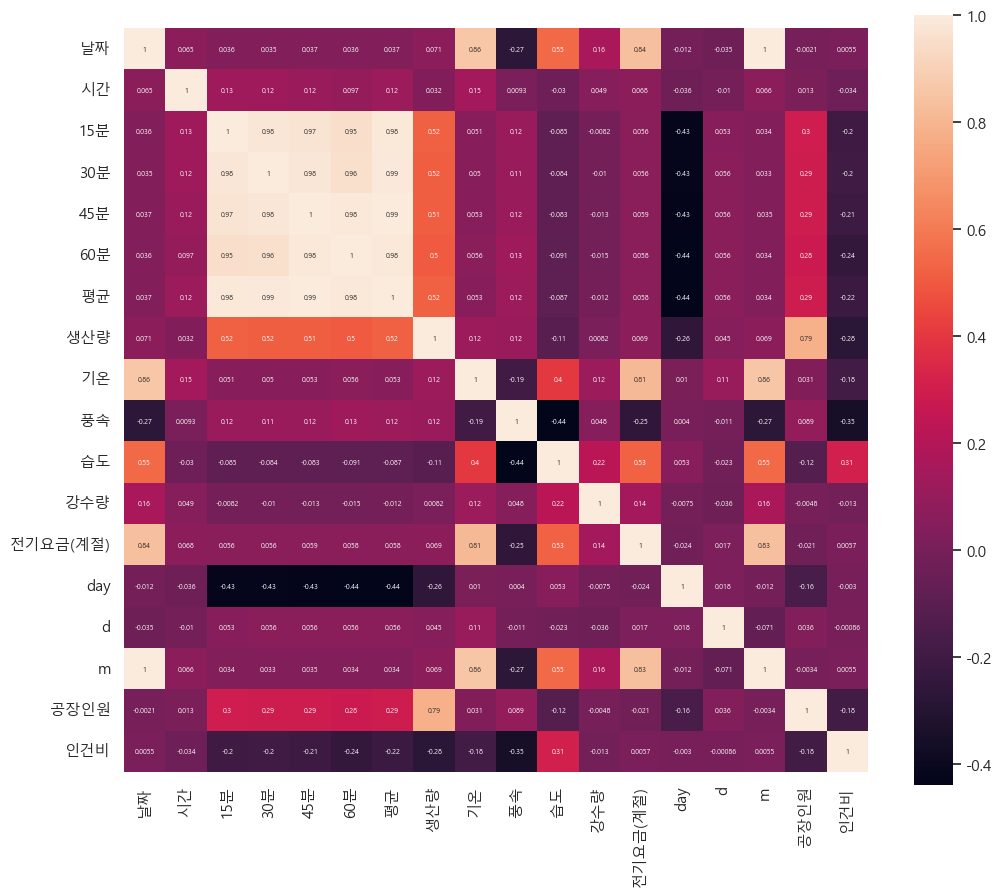

In [31]:
# [코드 16] heatmap()으로 상관관계 시각화 — 색이 밝을수록 양의 상관관계가 높음
#  한글이 깨지지 않도록 글꼴 지정 (가이드북은 Windows용 'Malgun Gothic')
#  (추가) macOS·Linux(Colab 등)에서도 돌아가도록 운영체제별 글꼴 선택 (Linux는 나눔고딕 설치 필요)
import platform
font_name = {'Windows': 'Malgun Gothic', 'Darwin': 'AppleGothic'}.get(platform.system(), 'NanumGothic')

plt.rc("font", family=font_name)
sns.set(font=font_name,
        rc={"axes.unicode_minus": False},
        style="darkgrid")
plt.figure(figsize=(12, 10))    # (추가) 18개 변수가 잘 보이도록 그림 크기 지정
sns.heatmap(df.corr(), vmax=1, square=True, annot=True, annot_kws={'size': 5})
plt.show()

→ 15분·30분·45분·60분·평균처럼 시간으로 이어진 최대수요전력끼리 상관관계가 매우 높고(0.9~1), 생산량은 0.5 정도의 상관관계를 보입니다. 이 실습에서는 상관관계가 높은 컬럼만 남겨 진행합니다.

#### ③-3. 데이터 정제

In [32]:
# [코드 17] drop(): 사용하지 않는 컬럼 제거 → 날짜, 시간, 15분, 30분, 45분, 60분, 평균만 남김
df = df.drop(columns=["생산량", "기온", "풍속", "습도", "강수량", "전기요금(계절)", "day", "d", "m", "공장인원", "인건비"])
df

[원자료 행이 보이는 출력이라 공개 저장소에서는 지웠습니다. 원자료를 data/raw/에 넣고 실행하면 다시 나옵니다.]


In [33]:
# [코드 18] rename(): 컬럼 이름을 영문으로 변경 {기존 이름: 새 이름}
df = df.rename(columns={"15분": "Peak Consumption in 15 minute",
                        "30분": "Peak Consumption in 30 minute",
                        "45분": "Peak Consumption in 45 minute",
                        "60분": "Peak Consumption in 60 minute",
                        "평균": "Average Peak Consumption in 1 hour"})
df.head()

[원자료 행이 보이는 출력이라 공개 저장소에서는 지웠습니다. 원자료를 data/raw/에 넣고 실행하면 다시 나옵니다.]


In [34]:
# [코드 19] date_range(): 2021-01-01 00시 ~ 2021-09-14 23시를 1시간 간격으로 만들어 새 인덱스로 사용
#  (가이드북 원본) freq='H' → pandas 2.2부터 대문자 'H'는 폐지 예정이라 소문자 'h' 사용
index_column = pd.date_range(start='2021-01-01 00:00', end='2021-09-14 23:00', freq='h')
index_column

(공개 저장소에서는 원자료 행이 보이는 출력을 지웠습니다. 실행하면 다시 나타납니다.)


In [35]:
# [코드 20] 인덱스를 날짜·시간으로 바꾸고 인덱스 이름을 'Date'로 지정
#  기존 인덱스 개수와 새 인덱스 개수(6,168개)가 같아야 오류가 나지 않습니다.
assert len(index_column) == len(df)     # (추가) 개수가 다르면 여기서 멈춤
df.index = index_column
df.index.names = ['Date']
df.head()

(공개 저장소에서는 원자료 행이 보이는 출력을 지웠습니다. 실행하면 다시 나타납니다.)


In [36]:
# [코드 21] 새 인덱스와 겹치는 날짜·시간 컬럼 제거
df = df.drop(columns=["날짜", "시간"])
df

(공개 저장소에서는 원자료 행이 보이는 출력을 지웠습니다. 실행하면 다시 나타납니다.)


In [37]:
# [코드 22] 데이터 일관성과 학습 계산을 위해 최대수요전력 값을 실수형(float)으로 변경
#  (가이드북 원본) [float(str(val).replace('.','').replace(',','.')) for val in ...]
#   → 정수 데이터에서는 astype(float)와 결과가 같고, 소수점이 있는 값이면 오히려 값이 틀어지므로 astype(float) 사용
for col in ['Peak Consumption in 15 minute', 'Peak Consumption in 30 minute',
            'Peak Consumption in 45 minute', 'Peak Consumption in 60 minute']:
    df[col] = df[col].astype(float)
df.head()

(공개 저장소에서는 원자료 행이 보이는 출력을 지웠습니다. 실행하면 다시 나타납니다.)


#### ③-4. 데이터 시각화 및 파일 저장
인덱스를 날짜로 바꿨기 때문에 연도·월·일 문자열로 원하는 기간만 골라 그릴 수 있습니다.

In [38]:
# [코드 23] seaborn 기본 스타일로 그림 크기를 가로 20, 세로 10으로 지정
#  (추가) sns.set()을 다시 부르면 글꼴이 초기화되므로 글꼴도 함께 지정
sns.set(font=font_name, rc={"figure.figsize": (20, 10), "axes.unicode_minus": False})

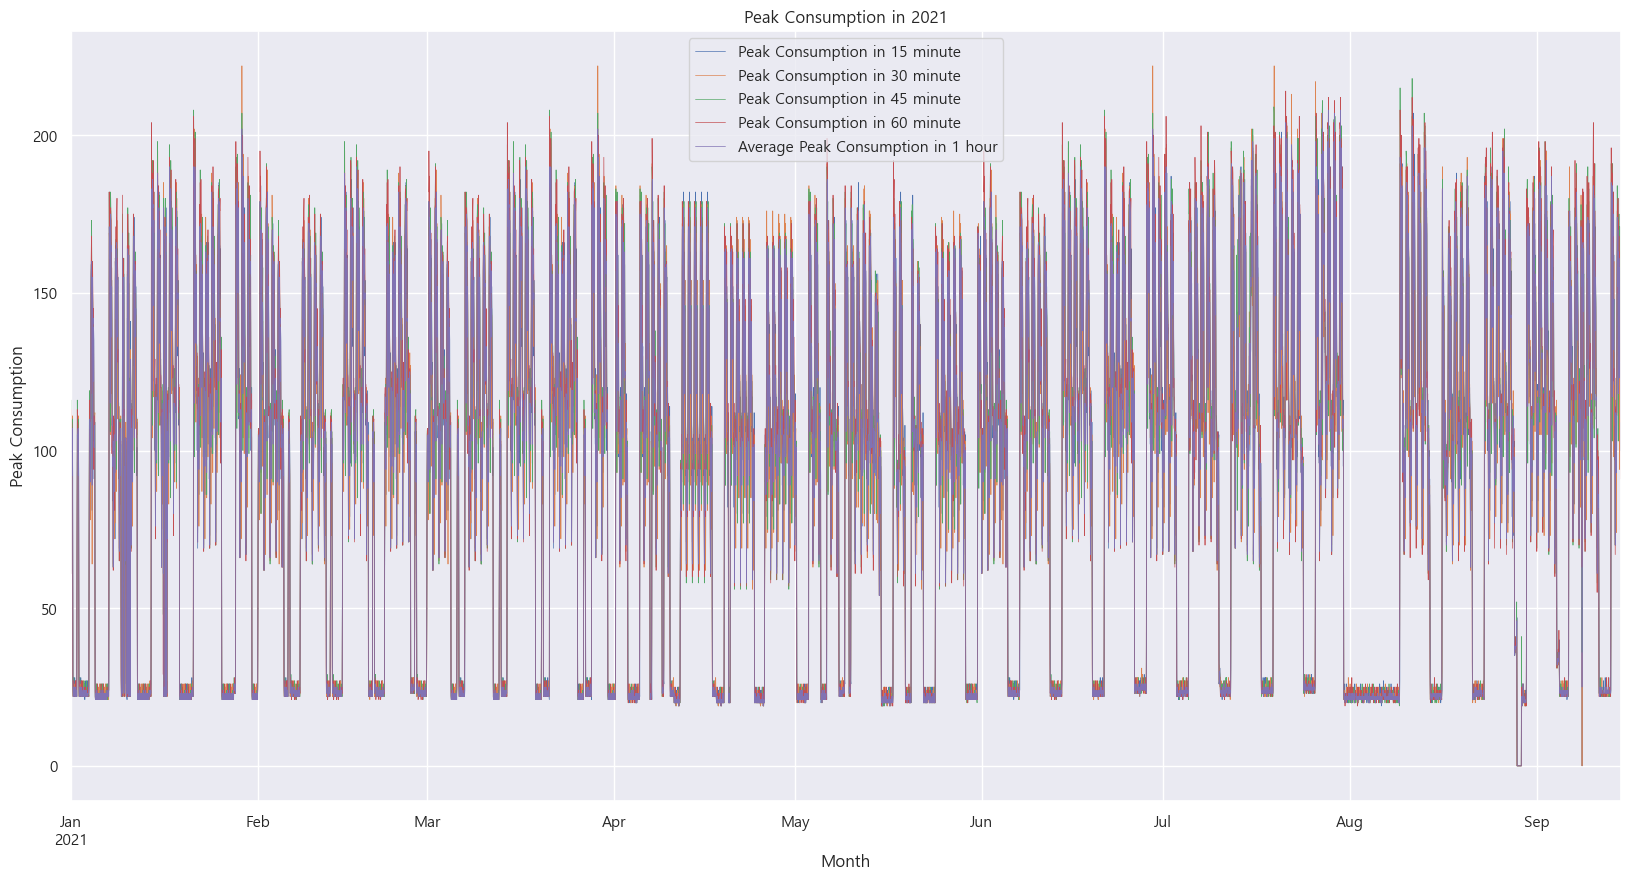

In [39]:
# [코드 24] 2021년 전체 최대수요전력 시각화 (그래프 제목, x축·y축 이름 지정)
#  (가이드북 원본) df["2021"] → pandas 2.0부터 행을 문자열로 고를 때는 .loc를 써야 함 ([코드 25~27]도 같음)
df.loc["2021"].plot(linewidth=0.5)
plt.title("Peak Consumption in 2021")
plt.xlabel("Month")
plt.ylabel("Peak Consumption")
plt.show()

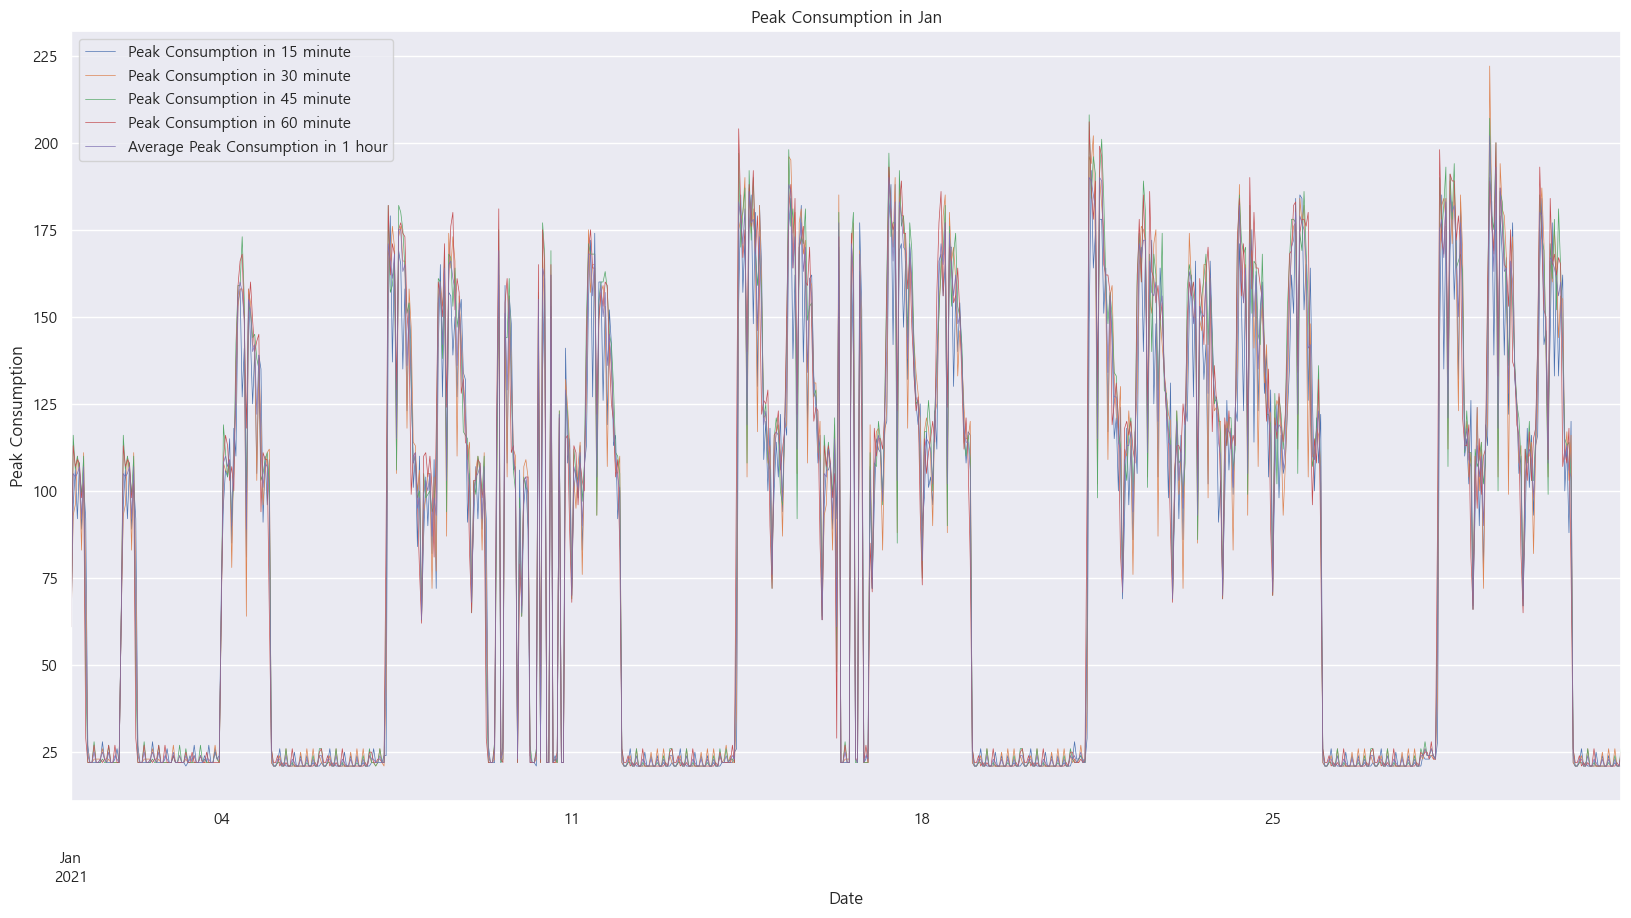

In [40]:
# [코드 25] 2021년 1월만 시각화
df.loc["2021-01"].plot(linewidth=0.5)
plt.title("Peak Consumption in Jan")
plt.ylabel("Peak Consumption")
plt.show()

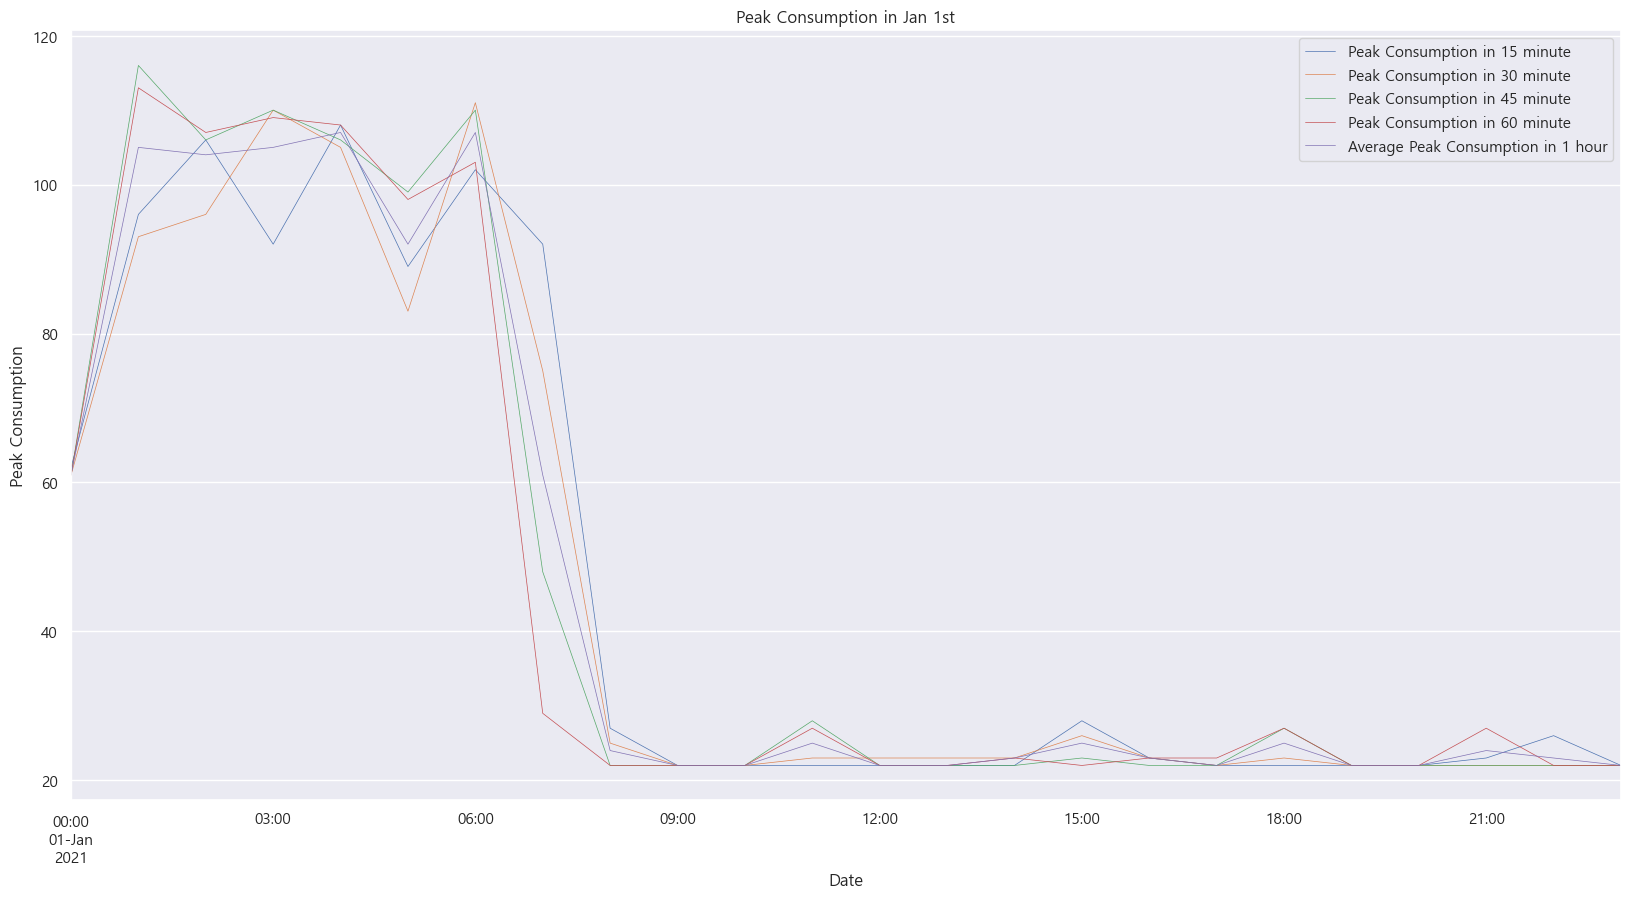

In [41]:
# [코드 26] 2021년 1월 1일 하루만 시각화
df.loc["2021-01-01"].plot(linewidth=0.5)
plt.title("Peak Consumption in Jan 1st")
plt.ylabel("Peak Consumption")
plt.show()

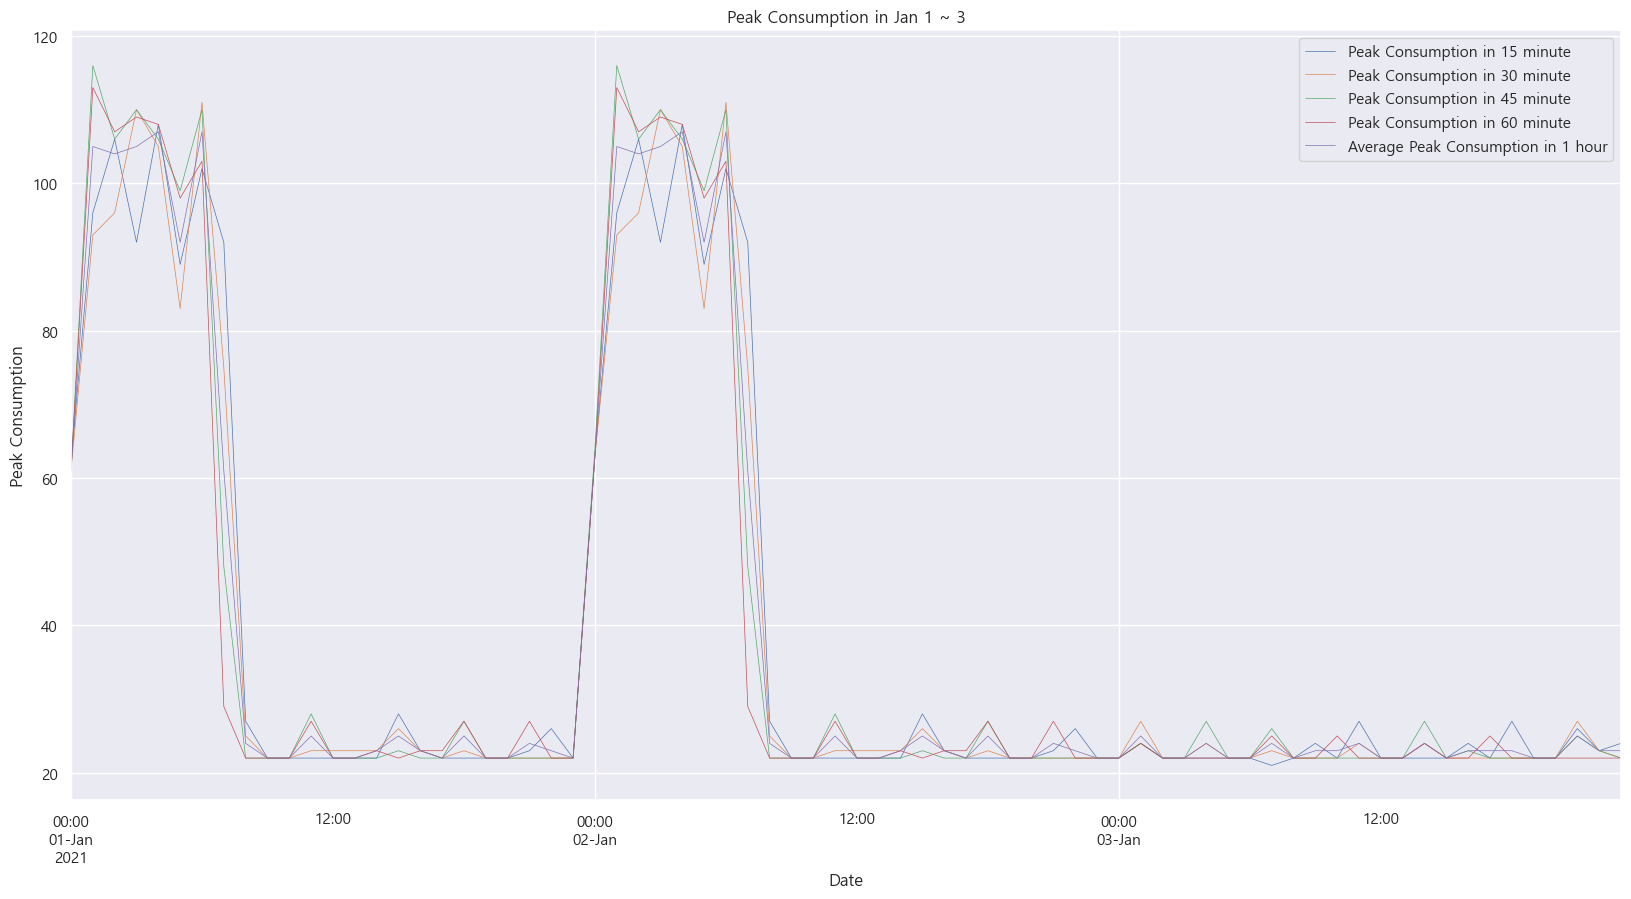

In [42]:
# [코드 27] 1월 1일 ~ 3일처럼 범위를 지정해 시각화
df.loc["2021-01-01":"2021-01-03"].plot(linewidth=0.5)
plt.title("Peak Consumption in Jan 1 ~ 3")
plt.ylabel("Peak Consumption")
plt.show()

#### ③-5. 주말 및 공휴일 데이터 구분
공장은 평일과 휴일의 전력 사용량 차이가 크므로 주말(Weekend)과 공휴일(Vacation) 여부를 컬럼으로 추가합니다.

In [43]:
# [코드 28] 공휴일(Vacation)·주말(Weekend) 컬럼을 추가하고 모든 행에 0 할당
df['Vacation'] = np.zeros(len(df))
df["Weekend"] = np.zeros(len(df))
df.head()

(공개 저장소에서는 원자료 행이 보이는 출력을 지웠습니다. 실행하면 다시 나타납니다.)


In [44]:
# [코드 29] dayofweek: 요일을 숫자로 반환 (월=0, 화=1, 수=2, 목=3, 금=4, 토=5, 일=6)
#  2021-01-01은 금요일이므로 4가 출력됩니다.
df.loc['2021-01-01'].index.dayofweek

Index([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4], dtype='int32', name='Date')

In [45]:
# [코드 30] 토요일(5) 또는 일요일(6)이면 Weekend에 1 할당 ('|'는 or)
#  (가이드북 원본) df['Weekend'][(조건)] = 1 → 체인 할당은 최신 pandas에서 반영되지 않을 수 있어 .loc 사용
df.loc[(df.index.dayofweek == 5) | (df.index.dayofweek == 6), 'Weekend'] = 1
df

(공개 저장소에서는 원자료 행이 보이는 출력을 지웠습니다. 실행하면 다시 나타납니다.)


In [46]:
# [코드 31] 2021-09-14까지의 공휴일(주말 제외) 목록
#  공휴일은 나라마다 다르고 설·추석은 음력이라 해마다 바뀌므로 직접 지정합니다.
holidays = ["2021-01-01", "2021-02-11", "2021-02-12", "2021-03-01", "2021-05-05", "2021-05-19", "2021-08-16"]

In [47]:
# [코드 32] iterrows()로 한 행씩 돌면서 날짜(str(gun)[:10], 예: '2021-01-01')가 holidays에 있으면 Vacation에 1 할당
#  (가이드북 원본) df["Vacation"].loc[gun] = 1 → 체인 할당 대신 df.loc[gun, "Vacation"] 사용
for gun, j in df.iterrows():
    if str(gun)[:10] in holidays:
        df.loc[gun, "Vacation"] = 1

In [48]:
# [코드 33] 공휴일인 1월 1일에 1이 들어갔는지 확인
df.head(5)

(공개 저장소에서는 원자료 행이 보이는 출력을 지웠습니다. 실행하면 다시 나타납니다.)


In [49]:
# [코드 34] 날짜 인덱스와 함께 csv로 저장 → ③-6에서 다시 불러와 사용
df.to_csv("daily_data_seasonality.csv", index=True)

#### ③-6. Window Features 생성
Window는 과거 몇 시간을 입력으로 볼지를 뜻합니다. 1주일 × 24시간 = **168**을 Window로 정하고, 각 시점마다 1~168시간 전의 15분 최대수요전력(`t-1` ~ `t-168`)을 컬럼으로 만듭니다.

In [50]:
# [코드 35] ③-5에서 저장한 파일 불러오기 (첫 번째 열 = 날짜 인덱스)
#  (가이드북 원본) pd.DataFrame(pd.read_csv(..., squeeze=True)) → squeeze 인자는 pandas 2.0에서 삭제되어 제거
daily_data = pd.read_csv("daily_data_seasonality.csv", header=0, index_col=0, parse_dates=True)

In [51]:
# [코드 36] 15분 최대수요전력만 사용 (30·45·60분도 같은 코드 구조로 예측할 수 있음)
#  ※ 가이드북 흐름대로 여기서 Weekend·Vacation 컬럼은 빠지므로 실제 RNN 입력에는 들어가지 않습니다.
daily_data = daily_data[["Peak Consumption in 15 minute"]]
daily_data

(공개 저장소에서는 원자료 행이 보이는 출력을 지웠습니다. 실행하면 다시 나타납니다.)


In [52]:
# [코드 37] 예측 시점(1시간 뒤)과 Window 크기(168시간) 선언
n_times_advance = 1
n_times_windows = 168

In [53]:
# [코드 38] 't-1' ~ 't-168' 컬럼 168개를 만들고 모든 행에 0 할당
#  (가이드북 원본) for문으로 컬럼을 하나씩 추가 → 한 번에 붙여서 같은 결과를 만들고 pandas 성능 경고를 피함
lag_columns = ["Peak Consumption in 15 minute_t-%i" % k
               for k in range(n_times_advance, n_times_advance + n_times_windows)]      # range(1, 169)
daily_data = pd.concat([daily_data, pd.DataFrame(0.0, index=daily_data.index, columns=lag_columns)], axis=1)
daily_data

(공개 저장소에서는 원자료 행이 보이는 출력을 지웠습니다. 실행하면 다시 나타납니다.)


In [54]:
# [코드 39] 0 대신 실제 과거 값 채우기: 't-j' 컬럼의 i번째 행 = (i-j)번째 행의 15분 최대수요전력
#  (가이드북 원본)
#   for i in range(n_times_advance + n_times_windows, len(daily_data["Peak Consumption in 15 minute"])):
#       for j in range(n_times_advance, n_times_advance + n_times_windows):
#           daily_data["Peak Consumption in 15 minute_t-%i" % j][i] = daily_data["Peak Consumption in 15 minute"][i-j]
#   → 약 100만 번 한 칸씩 대입해 매우 느리고, 최신 pandas에서는 체인 할당이라 값이 반영되지도 않음.
#     shift(j)는 값을 j칸 아래로 밀어 i번째 행에 (i-j)번째 값을 넣으므로 같은 결과를 한 번에 만듭니다.
for j in range(n_times_advance, n_times_advance + n_times_windows):
    daily_data["Peak Consumption in 15 minute_t-%i" % j] = daily_data["Peak Consumption in 15 minute"].shift(j)

In [55]:
# [코드 40] 과거 168시간이 모두 채워진 169번째 행(n_times_advance + n_times_windows)부터 사용 → 5,999행
daily_data = daily_data.iloc[n_times_advance + n_times_windows:]

In [56]:
# [코드 41] RNN 학습용 csv 저장 후 확인 — 각 열에 이전 시간대들의 최대수요전력이 들어가 있음
daily_data.to_csv("daily_data_seasonality_168.csv", index=True)
daily_data.head(3)

(공개 저장소에서는 원자료 행이 보이는 출력을 지웠습니다. 실행하면 다시 나타납니다.)


### [단계 ④] 훈련/테스트 데이터 분리
훈련 데이터는 학습에, 평가(테스트) 데이터는 학습 후 성능 평가에 씁니다. 7:3 같은 비율 대신 **날짜**로 나눠, 마지막 2021-09-01 ~ 09-14(24 × 14 = 336개)를 평가 데이터로 둡니다.

In [57]:
# [코드 42] 필요한 패키지 불러오기 2
import math
from sklearn.model_selection import train_test_split

In [58]:
# [코드 43] [단계 ③]에서 만든 daily_data_seasonality_168.csv 불러오기
#  (가이드북 원본) squeeze=True → pandas 2.0에서 삭제된 인자라 제거
daily_data_168 = pd.read_csv("daily_data_seasonality_168.csv",
                             header=0, index_col=0, parse_dates=True)
daily_data_168.head(3)

(공개 저장소에서는 원자료 행이 보이는 출력을 지웠습니다. 실행하면 다시 나타납니다.)


In [59]:
# [코드 44] 훈련 데이터 개수 = 전체 − 336 (9/1 ~ 9/14를 뺀 나머지 전부) → 5,663개
length_train_168 = len(daily_data_168) - 336
length_train_168

5663

값이 너무 크거나 작으면 학습 중 0으로 수렴하거나 무한대로 발산할 수 있어 스케일링을 합니다.
- **Standard Scaler**: 각 feature의 평균 0, 분산 1
- **Robust Scaler**: 평균·분산 대신 중앙값·사분위수 사용 → 이상치에 강함
- **MinMax Scaler**: 모든 feature를 0 ~ 1 사이로 변환 ← 이 분석에서 사용
- **Normalizer**: 열이 아닌 행 기준으로, 유클리드 거리가 1이 되도록 조정

In [60]:
# [코드 45] 필요한 패키지 불러오기 3
from sklearn.preprocessing import MinMaxScaler

In [61]:
# [코드 46] 값을 0~1 사이로 바꾸는 MinMax Scaler 생성
scaler_168 = MinMaxScaler(feature_range=(0, 1))
scaler_168

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [62]:
# [코드 47] fit_transform(): 컬럼별 최솟값·최댓값을 학습하고 0~1로 변환
#  ※ 가이드북대로 전체 데이터(훈련+테스트)로 fit합니다. 엄밀하게는 훈련 구간으로만 fit해야 테스트 정보가 새지 않습니다(개선 포인트).
daily_data_sc_168 = scaler_168.fit_transform(daily_data_168)
daily_data_sc_168

array([[0.42028986, 0.30917874, 0.53140097, ..., 0.44444444, 0.51207729,
        0.46376812],
       [0.50241546, 0.42028986, 0.30917874, ..., 0.52173913, 0.44444444,
        0.51207729],
       [0.43478261, 0.50241546, 0.42028986, ..., 0.42995169, 0.52173913,
        0.44444444],
       ...,
       [0.647343  , 0.59903382, 0.73429952, ..., 0.56521739, 0.50241546,
        0.64251208],
       [0.48309179, 0.647343  , 0.59903382, ..., 0.37681159, 0.56521739,
        0.50241546],
       [0.56521739, 0.48309179, 0.647343  , ..., 0.48309179, 0.37681159,
        0.56521739]], shape=(5999, 169))

In [63]:
# [코드 48] 스케일링한 값에서 앞쪽 5,663개를 훈련 데이터로
data_train_168 = daily_data_sc_168[:length_train_168]

In [64]:
# [코드 49] 마지막 336개(9/1 ~ 9/14)를 평가 데이터로
data_test_168 = daily_data_sc_168[-336:]

In [65]:
# [코드 50] 0번 열(현재 시점의 15분 최대수요전력)이 정답 Y, 나머지 168개 열(t-1 ~ t-168)이 입력 X
data_train_Y_168 = data_train_168[:, 0]
data_train_X_168 = data_train_168[:, 1:]
data_test_Y_168 = data_test_168[:, 0]
data_test_X_168 = data_test_168[:, 1:]
print(data_train_X_168.shape, data_train_Y_168.shape, data_test_X_168.shape, data_test_Y_168.shape)

(5663, 168) (5663,) (336, 168) (336,)


In [66]:
# [코드 51] RNN 입력 모양 (샘플 수, 시퀀스 길이, 특성 수)으로 변경: (5663, 168) → (5663, 24, 7)
#  ※ reshape은 앞에서부터 7개씩 자르므로 [t-1 ~ t-7], [t-8 ~ t-14], … 처럼 연속된 7개 값이 한 시점(step)이 됩니다.
data_train_X_168 = data_train_X_168.reshape((length_train_168, 24, 7))
data_train_X_168.shape

(5663, 24, 7)

### [단계 ⑤] 모델 구축 및 훈련
keras의 `Sequential()`에 `add()`로 층(layer)을 쌓아 단순 순환 신경망(SimpleRNN)을 만듭니다.
- `SimpleRNN(50)`: 은닉 상태(hidden state) 크기 50, 입력 모양 (24, 7)
- `Flatten()`: 다차원 출력을 1차원으로 펼침
- `Dense(1)`: 최대수요전력 1개 값을 예측
- Adam(learning_rate = 0.0001), 손실함수 MSE, epochs = 500 (전체 훈련 데이터를 500번 반복 학습)

> Windows에서는 TensorFlow가 CPU로만 동작하며(GPU는 WSL2 필요), 500 epoch 학습에 CPU 기준 약 5분이 걸립니다.

In [67]:
# [코드 52] 필요한 패키지 불러오기 4
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'    # (추가) TensorFlow 안내 로그 숨기기 (tensorflow를 불러오기 전에 설정)
import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, SimpleRNN, Flatten
tf.get_logger().setLevel('ERROR')           # (추가) 'Windows에서는 GPU 미지원' 같은 안내 경고 숨기기

In [68]:
# [코드 53] 단순 순환 신경망 구축 및 학습 (CPU에서 몇 분 걸림, 빠르게 테스트하려면 epochs를 줄이세요)
keras.utils.set_random_seed(42)     # (추가) 실행할 때마다 같은 결과가 나오도록 시드 고정

model_168 = Sequential()
# (가이드북 원본) model_168.add(SimpleRNN(50, input_shape=(24, 7))) → Keras 3 권장 방식대로 입력층을 따로 선언 (구조 동일)
model_168.add(keras.Input(shape=(24, 7)))
model_168.add(SimpleRNN(50))
model_168.add(Flatten())
model_168.add(Dense(1))

opt = tf.keras.optimizers.Adam(learning_rate=0.0001)
model_168.compile(loss='mean_squared_error', optimizer=opt)

# (추가) 500 epoch 로그가 너무 길어지지 않도록 50 epoch마다 한 줄씩만 출력
print_every_50 = keras.callbacks.LambdaCallback(
    on_epoch_end=lambda epoch, logs: print(f"Epoch {epoch + 1}/500 - loss: {logs['loss']:.6f}") if (epoch + 1) % 50 == 0 else None)
history = model_168.fit(data_train_X_168, data_train_Y_168, epochs=500, verbose=0, callbacks=[print_every_50])
model_168.summary()

Epoch 50/500 - loss: 0.006728


Epoch 100/500 - loss: 0.005296


Epoch 150/500 - loss: 0.004586


Epoch 200/500 - loss: 0.004085


Epoch 250/500 - loss: 0.003704


Epoch 300/500 - loss: 0.003408


Epoch 350/500 - loss: 0.003138


Epoch 400/500 - loss: 0.002898


Epoch 450/500 - loss: 0.002696


Epoch 500/500 - loss: 0.002532


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,855 (34.59 KB)

 Trainable params: 2,951 (11.53 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,904 (23.07 KB)

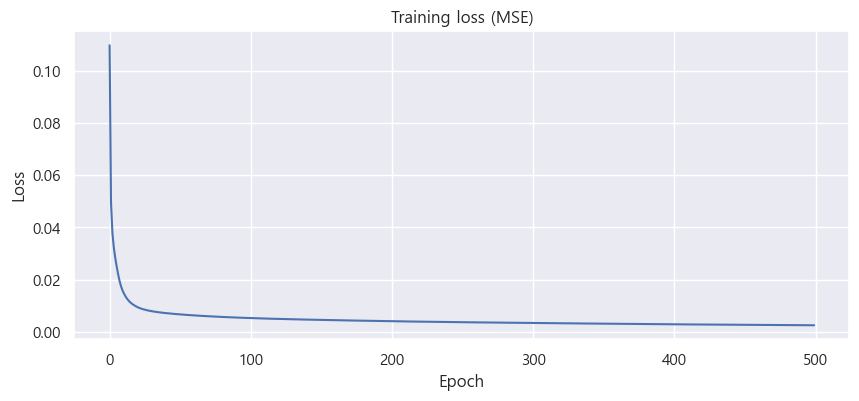

In [69]:
# (추가) 학습 손실(MSE) 곡선 — 500 epoch 동안 손실이 충분히 줄었는지 확인
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'])
plt.title("Training loss (MSE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [70]:
# [코드 54] 학습된 모델로 예측 — 테스트 입력도 훈련 데이터처럼 (336, 24, 7) 모양으로 바꿔서 넣음
preds_168 = model_168.predict(data_test_X_168.reshape((336, 24, 7)))

 1/11 ━━━━━━━━━━━━━━━━━━━━ 1s 161ms/step

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step 

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [71]:
# [코드 55] concatenate(): 예측값(1열)과 테스트 입력(168열)을 좌→우(axis=1)로 붙여 169열로 만들기
#  스케일러가 169열 기준으로 학습됐기 때문에 역변환하려면 같은 모양이어야 합니다. (axis=0이면 위→아래로 붙음)
data_predicted_168 = np.concatenate((preds_168, data_test_X_168), axis=1)
data_predicted_168

array([[0.32541749, 0.49758454, 0.52657005, ..., 0.55555556, 0.43478261,
        0.39130435],
       [0.47045806, 0.40096618, 0.49758454, ..., 0.43478261, 0.55555556,
        0.43478261],
       [0.51783627, 0.47342995, 0.40096618, ..., 0.52657005, 0.43478261,
        0.55555556],
       ...,
       [0.69832462, 0.59903382, 0.73429952, ..., 0.56521739, 0.50241546,
        0.64251208],
       [0.50144392, 0.647343  , 0.59903382, ..., 0.37681159, 0.56521739,
        0.50241546],
       [0.51381266, 0.48309179, 0.647343  , ..., 0.48309179, 0.37681159,
        0.56521739]], shape=(336, 169))

In [72]:
# [코드 56] inverse_transform(): 0~1로 스케일링된 값을 실제 전력 단위로 되돌려 실제값과 비교할 수 있게 함
data_predicted_168 = scaler_168.inverse_transform(data_predicted_168)
data_predicted_168

array([[ 67.36142018, 103.        , 109.        , ..., 115.        ,
         90.        ,  81.        ],
       [ 97.38481852,  83.        , 103.        , ...,  90.        ,
        115.        ,  90.        ],
       [107.19210845,  98.        ,  83.        , ..., 109.        ,
         90.        , 115.        ],
       ...,
       [144.55319649, 124.        , 152.        , ..., 117.        ,
        104.        , 133.        ],
       [103.79889196, 134.        , 124.        , ...,  78.        ,
        117.        , 104.        ],
       [106.35922086, 100.        , 134.        , ..., 100.        ,
         78.        , 117.        ]], shape=(336, 169))

In [73]:
# [코드 57] 예측값(0번 열)에 2021-09-01 00시 ~ 09-14 23시 날짜 인덱스를 붙여 csv로 저장
index_column = pd.date_range(start='2021-09-01 00:00', end='2021-09-14 23:00', freq='h')
best_pred_168 = pd.DataFrame(data=data_predicted_168[:, 0],
                             index=index_column)
best_pred_168.rename(columns={0: "forecasting"}, inplace=True)
best_pred_168.to_csv("the_best_rnn_pred_168.csv", index=True)
best_pred_168.head()

(공개 저장소에서는 원자료 행이 보이는 출력을 지웠습니다. 실행하면 다시 나타납니다.)


### [단계 ⑥] 분석 시각화
실제값과 예측값을 한 데이터셋으로 묶어 그래프로 비교합니다.

In [74]:
# [코드 58] 비교할 실제값: 스케일링 전 15분 최대수요전력 원본
data_original = daily_data[["Peak Consumption in 15 minute"]]

In [75]:
# [코드 59] 저장해 둔 RNN 예측값 불러오기
forecast = pd.read_csv('./the_best_rnn_pred_168.csv')['forecasting']
forecast

0       67.361420
1       97.384819
2      107.192108
3       96.672339
4      109.548660
          ...    
331    158.224398
332    125.887236
333    144.553196
334    103.798892
335    106.359221
Name: forecasting, Length: 336, dtype: float64

In [76]:
# [코드 60] 실제값 중 예측 구간과 같은 마지막 336개(9/1 ~ 9/14)만 가져오기
#  (가이드북 원본) [...]['Peak Consumption in 15 minute'][-336:] → 위치 기준임을 분명히 하려고 .iloc 사용
compare_result = pd.DataFrame(np.array(data_original['Peak Consumption in 15 minute'].iloc[-336:]), columns=['Original 15 minute'])

In [77]:
# [코드 61] 예측값 컬럼을 추가해 실제값·예측값을 하나의 데이터셋으로 구성
compare_result['forecasting'] = forecast
compare_result

,Original 15 minute,forecasting
0,83.0,67.361420
1,98.0,97.384819
2,121.0,107.192108
3,90.0,96.672339
4,114.0,109.548660
...,...,...
331,152.0,158.224398
332,124.0,125.887236
333,134.0,144.553196
334,100.0,103.798892


In [78]:
# [코드 62] 비교용 날짜 인덱스(9/1 00시 ~ 9/14 23시) 생성
index_column = pd.date_range(start='2021-09-01 00:00', end='2021-09-14 23:00', freq='h')
index_column

(공개 저장소에서는 원자료 행이 보이는 출력을 지웠습니다. 실행하면 다시 나타납니다.)


In [79]:
# [코드 63] 날짜 인덱스 설정 (인덱스 이름 'Date')
compare_result.index = index_column
compare_result.index.names = ['Date']
compare_result.head()

(공개 저장소에서는 원자료 행이 보이는 출력을 지웠습니다. 실행하면 다시 나타납니다.)


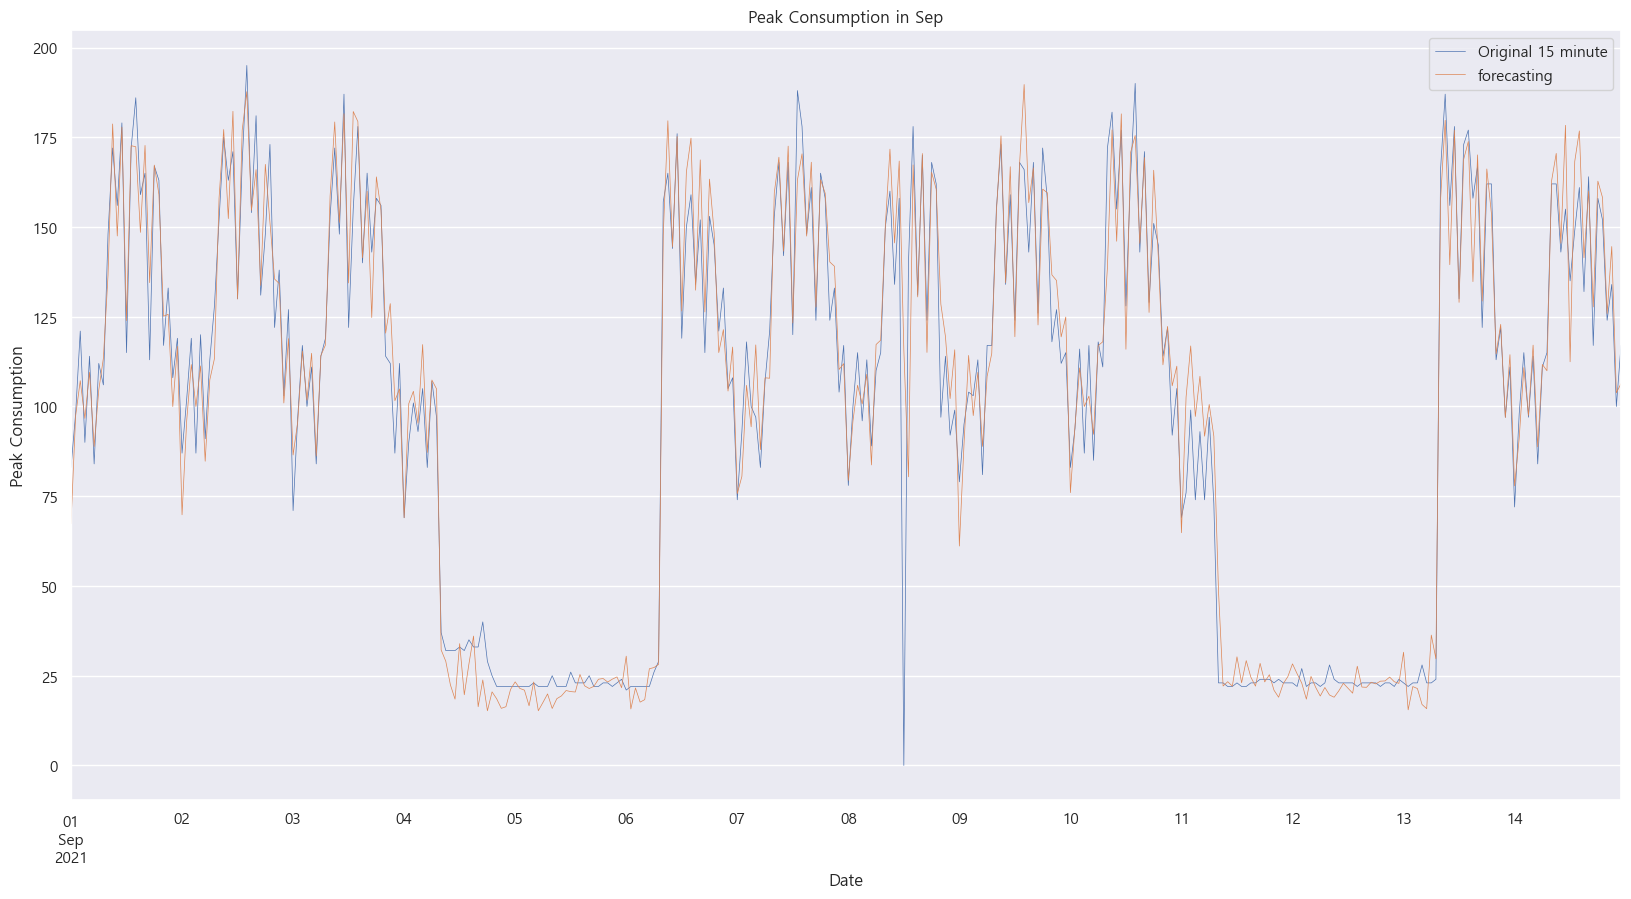

In [80]:
# [코드 64] 9월 실제값(Original) vs 예측값(forecasting) 시각화
compare_result.loc["2021-09"].plot(linewidth=0.5)
plt.title("Peak Consumption in Sep")
plt.ylabel("Peak Consumption")
plt.show()

In [81]:
# (추가) Baseline 성능 지표 — 테스트 구간(9/1 ~ 9/14, 336시간)의 오차
#  가이드북은 그래프로만 비교하므로, 개선 모델과 비교할 수 있게 수치로도 남깁니다.
from sklearn.metrics import mean_squared_error, mean_absolute_error
rnn_mse = mean_squared_error(compare_result['Original 15 minute'], compare_result['forecasting'])
rnn_mae = mean_absolute_error(compare_result['Original 15 minute'], compare_result['forecasting'])
print(f"RNN test MSE : {rnn_mse:.2f}")
print(f"RNN test RMSE: {math.sqrt(rnn_mse):.2f}")
print(f"RNN test MAE : {rnn_mae:.2f}")

RNN test MSE : 132.50
RNN test RMSE: 11.51
RNN test MAE : 7.16


→ 가이드북 해석: 일자 단위로 보면 실제값과 예측값이 대체로 일치하지만, 시간별로 보면 **주말 데이터를 제대로 반영하지 못합니다.** 이 문제를 보완하려고 랜덤 포레스트로 최대수요전력 예측과 자원 최적화를 추가로 진행합니다.

## 3. 분석 단계별 프로세스 — 랜덤 포레스트(RF) 알고리즘 (가이드북 2.3-3)
단계 ① 라이브러리/데이터 불러오기 → ② 데이터 종류 및 개수 확인 → ③ 데이터 정제(전처리) → ④ 랜덤 포레스트 모델 학습 및 결과분석(+ 자원 최적화)

기상·시간·요일 정보와 현재 15분 구간의 최대수요전력으로 **다음 15분 구간의 최대수요전력**을 예측하고, 그 예측값으로 전기료와 인건비를 최소화하는 인력 투입안을 찾습니다.

### [단계 ①] 라이브러리/데이터 불러오기

In [82]:
# [코드 65] 필요한 패키지 불러오기 5
import os
import sklearn

In [83]:
# [코드 66] RNN [코드 12]에서 결측치만 0으로 채워 저장해 둔 df_frame 사용 (18개 컬럼 전체)
df_frame

[원자료 행이 보이는 출력이라 공개 저장소에서는 지웠습니다. 원자료를 data/raw/에 넣고 실행하면 다시 나옵니다.]


### [단계 ②] 데이터 종류 및 개수 확인

In [84]:
# [코드 67] head()로 데이터 구성 확인
df_frame.head()

[원자료 행이 보이는 출력이라 공개 저장소에서는 지웠습니다. 원자료를 data/raw/에 넣고 실행하면 다시 나옵니다.]


In [85]:
# [코드 68] info()로 구조·타입 확인 — 결측 없이 모든 컬럼이 같은 형태(int64/float64)이므로 일관성을 만족
df_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6168 entries, 0 to 6167
Data columns (total 18 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   날짜        6168 non-null   int64  
 1   시간        6168 non-null   int64  
 2   15분       6168 non-null   int64  
 3   30분       6168 non-null   int64  
 4   45분       6168 non-null   int64  
 5   60분       6168 non-null   int64  
 6   평균        6168 non-null   int64  
 7   생산량       6168 non-null   int64  
 8   기온        6168 non-null   float64
 9   풍속        6168 non-null   float64
 10  습도        6168 non-null   int64  
 11  강수량       6168 non-null   float64
 12  전기요금(계절)  6168 non-null   float64
 13  day       6168 non-null   int64  
 14  d         6168 non-null   int64  
 15  m         6168 non-null   int64  
 16  공장인원      6168 non-null   float64
 17  인건비       6168 non-null   float64
dtypes: float64(6), int64(12)
memory usage: 867.5 KB


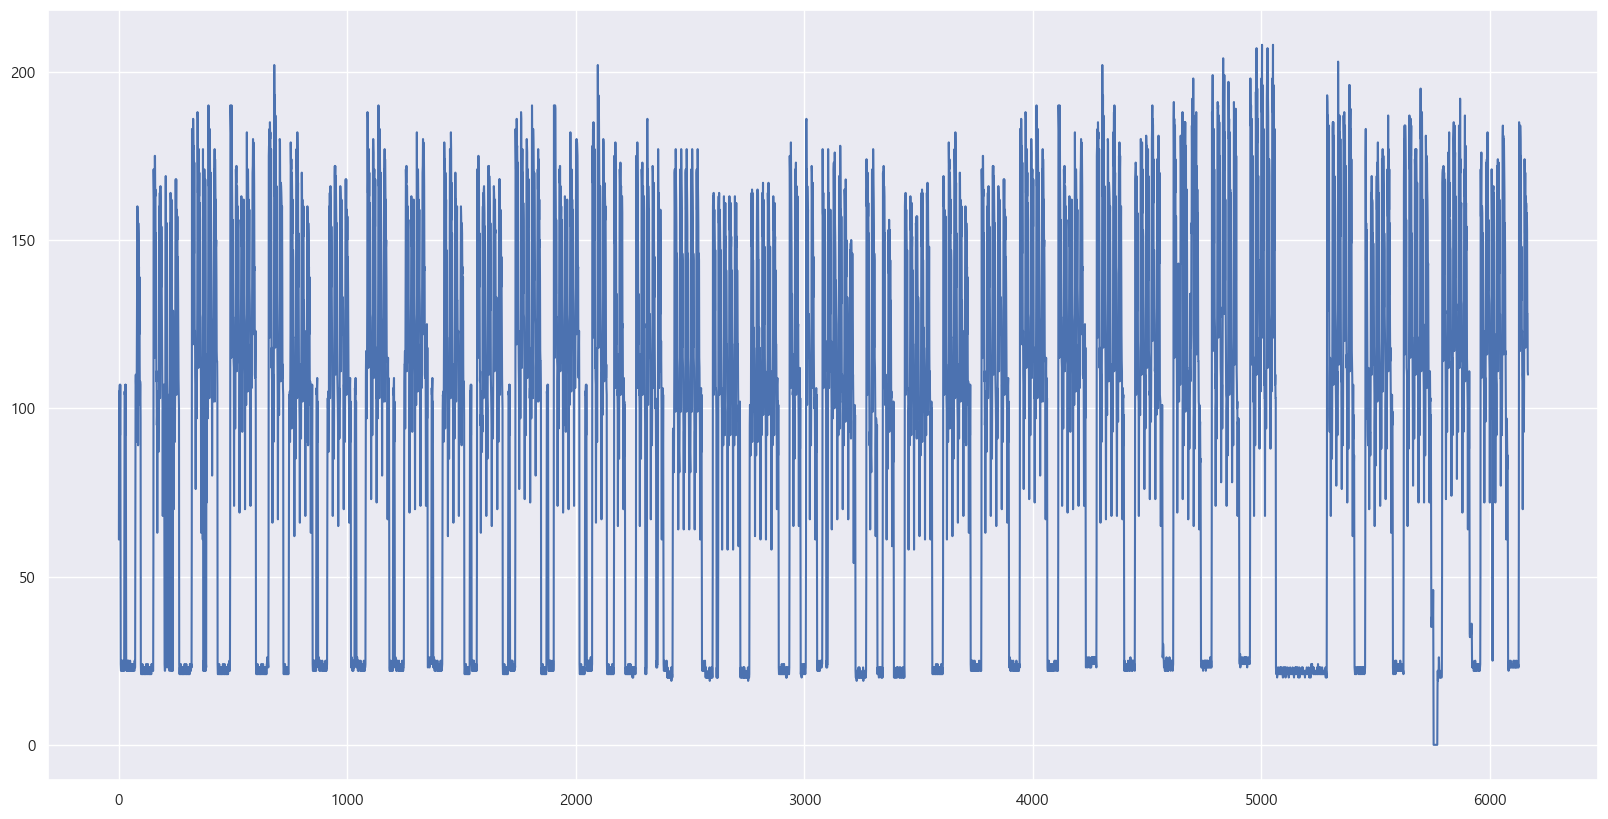

In [86]:
# [코드 69] 예측 대상인 '15분'~'60분'의 평균('평균' 컬럼)이 시간에 따라 어떻게 변하는지 확인
plt.plot(df_frame['평균'])
plt.show()

### [단계 ③] 데이터 정제 (전처리)
#### ③-1. 불필요 데이터 제거

In [87]:
# [코드 70] RF에서 쓰지 않는 '평균'과 '날짜' 컬럼 제거
df_frame.drop(['평균', '날짜'], axis=1, inplace=True)

# (추가·선택) 1-3에서 찾은 '시간' 오류(7/13, 7/15의 48행) 보정 — 가이드북에 없는 단계라 기본은 주석 처리
#  날짜마다 24행이 0~23시 순서로 있으므로 행 순서대로 시간을 다시 매길 수 있습니다.
# df_frame['시간'] = np.tile(np.arange(24), len(df_frame) // 24)
df_frame

,시간,15분,30분,45분,60분,생산량,기온,풍속,습도,강수량,전기요금(계절),day,d,m,공장인원,인건비
0,0,62,61,61,61,0,-3.2,2.4,71,0.0,109.8,5,1,1,0.000000,1.5
1,1,96,93,116,113,0,-4.5,1.5,77,0.0,109.8,5,1,1,0.000000,1.5
2,2,106,96,106,107,0,-3.9,2.6,58,0.0,109.8,5,1,1,0.000000,1.5
3,3,92,110,110,109,0,-4.1,2.6,56,0.0,109.8,5,1,1,0.000000,1.5
4,4,108,105,106,108,0,-4.6,2.6,60,0.0,109.8,5,1,1,0.000000,1.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6163,19,152,151,171,139,1497,21.7,3.6,85,9.4,167.2,2,14,9,2.442088,1.5
6164,20,124,130,128,130,45,22.2,4.2,78,9.4,167.2,2,14,9,0.087891,1.5
6165,21,134,130,125,124,149,22.2,4.3,76,9.4,167.2,2,14,9,0.290448,1.5
6166,22,100,109,120,114,66,22.0,2.5,79,9.4,167.2,2,14,9,0.148984,1.5


#### ③-2. 결측치 값 처리

In [88]:
# [코드 71] 컬럼별 결측치 비율 확인 → 모두 0% (RNN [코드 12]에서 이미 0으로 채움)
for col in df_frame.columns:
    null_count = 'column: {:>10}\t Percent of NaN value: {:.2f}%'.format(col, 100 * (df_frame[col].isnull().sum() / df_frame[col].shape[0]))
    print(null_count)

column:         시간	 Percent of NaN value: 0.00%
column:        15분	 Percent of NaN value: 0.00%
column:        30분	 Percent of NaN value: 0.00%
column:        45분	 Percent of NaN value: 0.00%
column:        60분	 Percent of NaN value: 0.00%
column:        생산량	 Percent of NaN value: 0.00%
column:         기온	 Percent of NaN value: 0.00%
column:         풍속	 Percent of NaN value: 0.00%
column:         습도	 Percent of NaN value: 0.00%
column:        강수량	 Percent of NaN value: 0.00%
column:   전기요금(계절)	 Percent of NaN value: 0.00%
column:        day	 Percent of NaN value: 0.00%
column:          d	 Percent of NaN value: 0.00%
column:          m	 Percent of NaN value: 0.00%
column:       공장인원	 Percent of NaN value: 0.00%
column:        인건비	 Percent of NaN value: 0.00%


#### ③-3. 데이터 정리
1시간 1행(15·30·45·60분)을 15분 1행으로 펼쳐 6,168 × 4 = 24,672개의 샘플을 만들고, 각 샘플의 정답은 **바로 다음 15분 구간**의 최대수요전력으로 둡니다. 예를 들어 x[0]이 1월 1일 0시의 '15분'(0~15분) 값이면 y[0]은 '30분'(15~30분) 값입니다.
- `x_train`: [시간, 기온, 풍속, 습도, 강수량, day, d, m] + 현재 15분 구간의 최대수요전력 → 9개 피처
- `y_labels`: 다음 15분 구간의 최대수요전력
- `cost_list`: 최적화에만 쓰는 [인건비, 전기요금(계절), 공장인원, 생산량] → 모델 입력에서는 제외

In [89]:
# [코드 72] 회귀 모델 학습을 위한 데이터 재구성
label_cat_names = ['15분', '30분', '45분', '60분']
or_cat_rm_list = ["인건비", "전기요금(계절)", "공장인원", "생산량"]

# (변경) 가이드북은 반복문 안에서 매번 drop()했지만, 결과가 같으므로 피처 표와 비용 표를 미리 한 번만 만들어 둠
feature_frame = df_frame.drop(or_cat_rm_list, axis=1).drop(label_cat_names, axis=1)   # 시간, 기온, 풍속, 습도, 강수량, day, d, m
cost_frame = df_frame[or_cat_rm_list]

x_train = []
cost_list = []
for index in range(0, len(df_frame)):
    for col in label_cat_names:
        # (가이드북 원본) temp = list(df_frame.drop(or_cat_rm_list,axis=1).drop(label_cat_names,axis=1).iloc[0])
        #  → .iloc[0]이면 모든 샘플이 첫 행(1/1 0시)의 시간·기온·요일 값을 쓰게 되는 오류라 현재 행(index)으로 수정
        #    가이드북 수치(MSE 185.98 / 183.06)를 그대로 재현하려면 아래의 index를 0으로 바꾸면 됩니다.
        temp = list(feature_frame.iloc[index])
        temp.append(df_frame[col][index])            # 마지막 피처 = 현재 15분 구간의 최대수요전력
        cost_list.append(cost_frame.iloc[index])
        x_train.append(temp)

y_labels = []
for index in range(0, len(df_frame)):
    for col in label_cat_names:
        y_labels.append(df_frame[col][index])

# 정답은 '다음' 15분 값이므로 y의 첫 값을 빼고, 짝이 없는 x·cost의 마지막 값을 뺌 → 24,671개
y_labels.pop(0)
x_train.pop(len(x_train) - 1)
# (가이드북 원본) cost_list.pop(len(x_train)-1) → 마지막이 아닌 끝에서 두 번째를 지움 (두 값이 같은 행이라 결과는 같음)
cost_list.pop(len(cost_list) - 1)

X = np.asarray(x_train)
C = np.asarray(cost_list)
y = np.asarray(y_labels)
print(X.shape, C.shape, y.shape)

(24671, 9) (24671, 4) (24671,)


### [단계 ④] 랜덤 포레스트 모델 학습 및 결과분석
#### ④-1. 사용할 모델 구축, 학습 및 검증

In [90]:
# [코드 73] 필요한 패키지 불러오기 6
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.utils.random import sample_without_replacement

In [91]:
# [코드 74] train_test_split: 무작위로 섞어 학습 70% / 검증 30%로 분리 (random_state=42로 고정해 매번 같은 분리)
#  C도 같은 random_state로 나누므로 x_test[i]와 c_test[i]는 같은 샘플을 가리킵니다.
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
c_train, c_test, cy_train, cy_test = train_test_split(C, y, test_size=0.3, random_state=42)
print(x_train.shape, x_test.shape)

(17269, 9) (7402, 9)


In [92]:
# [코드 75] 랜덤 포레스트 회귀 모델 선언 및 학습 — 여러 결정 트리의 예측을 평균내는 앙상블 모델
#  트리의 최대 깊이 20, random_state 42 고정
forest_reg = RandomForestRegressor(max_depth=20, random_state=42)
forest_reg.fit(x_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [93]:
# [코드 76] 학습 데이터에 대한 평균 제곱 오차(MSE) — MSE = (1/n) Σ (실제값 − 예측값)²
rf_train_mse = mean_squared_error(forest_reg.predict(x_train), y_train)
rf_train_mse

30.306276142687416

In [94]:
# [코드 77] 검증 데이터에 대한 평균 제곱 오차
rf_test_mse = mean_squared_error(forest_reg.predict(x_test), y_test)
rf_test_mse

145.38214245758513

→ 가이드북 원본 [코드 72](모든 샘플이 첫 행의 피처 사용)의 결과는 학습 MSE 185.98 / 검증 MSE 183.06입니다. 피처를 현재 행으로 고치면 학습 30.31 / 검증 145.38로, 기상·시간 정보가 실제로 반영되면서 검증 오차가 약 21% 줄어듭니다. 학습 오차가 검증 오차보다 훨씬 작아 과적합 경향이 있으므로 `max_depth` 등을 조정해 볼 수 있습니다.

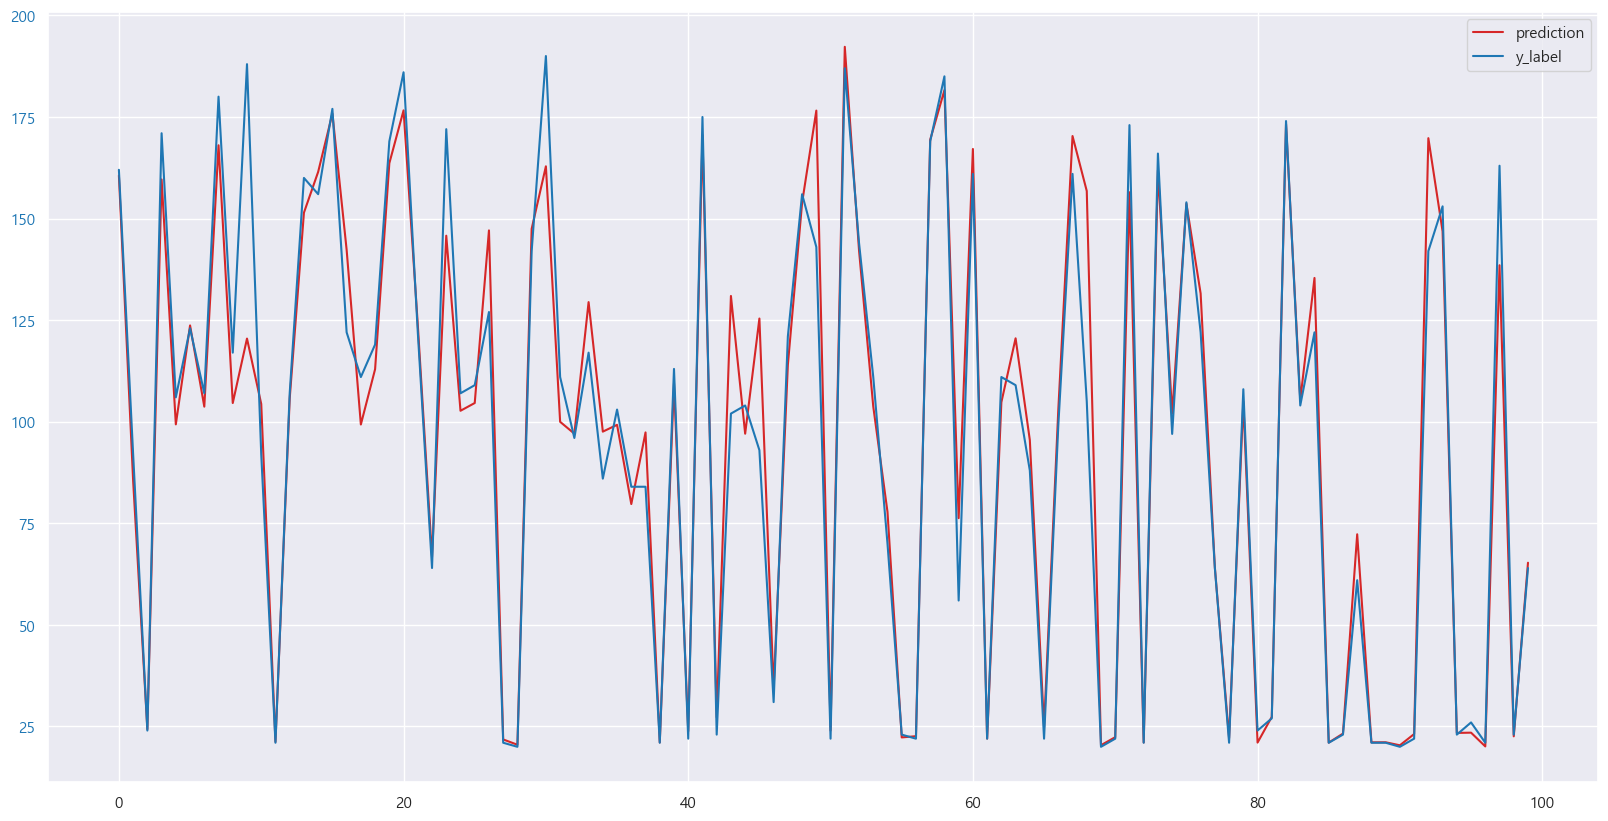

In [95]:
# [코드 78] 검증 데이터 중 무작위 100개를 뽑아 예측값(빨강)과 실제값(파랑) 비교
#  (추가) random_state=42로 매번 같은 100개가 뽑히도록 고정
prediction = forest_reg.predict(x_test)
predicted_sample_indexes = sample_without_replacement(len(prediction), 100, random_state=42)
color = 'tab:red'
plt.tick_params(axis='y', labelcolor=color)
plt.plot(prediction[predicted_sample_indexes], color=color)
color = 'tab:blue'
plt.plot(y_test[predicted_sample_indexes], color=color)
plt.tick_params(axis='y', labelcolor=color)
plt.legend(['prediction', 'y_label'])
plt.show()

#### ④-2. 자원 최적화 및 분석
④-1에서 예측한 최대수요전력으로, 공장 비용을 최소로 만드는 변수를 찾습니다. 문제를 단순하게 하려고 계절별 전기가격과 시간당 인건비의 합을 최소화합니다.

$$Cost = P_{human} + P_{electric}$$

- 결정 변수: $x = P_{electric}$ (1 ≤ x ≤ 2, 1이면 낮), $y = P_{human}$ (투입 공장인원, 1 ≤ y ≤ 75명)
- 추가 제약: 11 ≤ x + 2y ≤ 95
- 최적화는 목적값인 **생산량이 0이 아닌 시점**에만 적용합니다. (어떤 생산량을 달성하는 데 필요한 최소 자원을 찾는 과정이므로)

In [96]:
# [코드 79] 목적함수 계수 계산 — 전기료(total_elec_price)와 인건비(total_human_cost)
#  prediction[index] : RF가 예측한 다음 15분 구간의 최대수요전력
#  c_test[index]     : [0] 인건비 비율, [1] 전기요금(계절), [2] 공장인원, [3] 생산량   (or_cat_rm_list 순서)
#  x_test[index]     : [-1] 현재 15분 구간의 최대수요전력, [-2] 월(m)
def build_objective_function_parameters(prediction, x_test, c_test, index=0):
    total_elec_price = prediction[index] * c_test[index][1] / 1000 + x_test[index][-1] * 1.1 - x_test[index][-2] * 1.1
    total_human_cost = c_test[index][2] * 50 - x_test[index][-1] * 1.1 + x_test[index][-2] * 1.1
    return total_elec_price, total_human_cost

In [97]:
# [코드 80] 필요한 패키지 불러오기 7 — Google OR-Tools의 선형계획(Linear Programming) solver
from ortools.linear_solver import pywraplp

In [98]:
# [코드 81] 목적함수 구성
#  낮에는 전기료가 비싸고 인건비가 싸며, 밤에는 반대입니다. 두 비용이 반대 성질이라 한쪽 계수에 음수를 곱합니다.
#  인건비 비율 c_test[index][0]이 1이면 주간 요율, 아니면(1.5) 야간 요율로 보고 계수를 다르게 둡니다.
#  목적함수를 최소화하는 것이 목표이므로 SetMinimization()을 사용합니다.
def objective_function(solver, c_test, cx, cy, x, y, index=0):
    objective = solver.Objective()
    if (c_test[index][0] == 1):
        objective.SetCoefficient(x, cx * 2)
        objective.SetCoefficient(y, -cy)

    else:
        objective.SetCoefficient(x, cx // 2)
        objective.SetCoefficient(y, -(cy) // 2)
    objective.SetMinimization()
    return objective

In [99]:
# [코드 82] 최적화 함수 — 변수와 제약조건을 선언하고 GLOP(선형계획) solver로 풀기
#  x: 1 ≤ x ≤ 2 (전기 사용 시간대), y: 1 ≤ y ≤ 75 (투입 공장인원 수), 제약: 11 ≤ x + 2y ≤ 95
#  ※ 가이드북 [그림 21]의 식은 2x + y 이지만, 가이드북 결과(610.42)는 이 코드(x + 2y)로 계산된 값이라 코드를 따름
def get_solution(pred, x_test, c_test, index=118):
    solver = pywraplp.Solver.CreateSolver('GLOP')
    x = solver.NumVar(1, 2, 'x')
    y = solver.NumVar(1, 75, 'y')
    tep, thc = build_objective_function_parameters(pred, x_test, c_test, index)
    objective = objective_function(solver, c_test, tep, thc, x, y, index)
    objective = solver.Objective()
    constraint2 = solver.Constraint(11, 95)
    constraint2.SetCoefficient(x, 1)
    constraint2.SetCoefficient(y, 2)

    solver.Solve()

    opt_solution = tep * x.solution_value() - thc * y.solution_value()
    print("1이면 낮, 0이면 밤 : ", x.solution_value())
    print("공장인원 수 : ", y.solution_value())
    print("final solution: ", opt_solution)
    # (가이드북 원본) c_test[index][-2] → 공장인원 값이므로 생산량인 c_test[index][-1]로 수정
    if x.solution_value() == 1:
        print("생산량이 ", c_test[index][-1], "일 때, 낮에 공장직원 ", y.solution_value(), "을 투입 시켜야한다.")
    else:
        print("생산량이 ", c_test[index][-1], "일 때, 밤에 공장직원 ", y.solution_value(), "을 투입 시켜야한다.")
    return x.solution_value(), y.solution_value(), opt_solution    # (추가) 결과 요약에 쓰려고 반환

In [100]:
# [코드 83] 생산량이 0이 아닌 검증 데이터 중 111번째 샘플의 생산량 확인
#  (가이드북 원본) c_test[111][-2] → 출력값 0.1718…은 공장인원이므로 생산량인 [-1]로 수정
print('생산량 :', c_test[111][-1])

생산량 : 72.0


In [101]:
# [코드 84] get_solution()으로 111번째 검증 데이터의 최적화 결과 확인
opt_x, opt_y, opt_cost = get_solution(prediction, x_test, c_test, 111)

1이면 낮, 0이면 밤 :  1.0
공장인원 수 :  5.0
final solution:  568.1274607500001
생산량이  72.0 일 때, 낮에 공장직원  5.0 을 투입 시켜야한다.


→ 검증 데이터 111번째 상황에서는 낮(x = 1)에 공장직원 5명(y = 5)을 투입하는 것이 전기료를 포함한 공장 운영 비용을 최소화합니다. 가이드북 원본 결과(목적함수 약 610)와 결정(x = 1, y = 5)은 같고, [코드 72] 수정으로 예측값이 달라져 목적함수 값만 바뀝니다.

## 4. Baseline 결과 요약 (추가)

In [102]:
# (추가) Baseline 결과 요약 — 이후 개선 실험(피처 추가, 하이퍼파라미터 조정 등)과 비교할 기준값
#  ※ RNN(1시간 뒤의 15분 피크, 날짜로 분할)과 RF(다음 15분 구간, 무작위 분할)는 예측 대상과 분할 방식이 달라
#    두 모델의 수치를 서로 직접 비교하면 안 됩니다. 같은 모델의 개선 전후를 비교할 때 쓰세요.
rf_train_pred = forest_reg.predict(x_train)
summary = pd.DataFrame(
    [['RNN (SimpleRNN 50, window 168)', '테스트 2021-09-01 ~ 09-14', len(compare_result), rnn_mse, rnn_mae],
     ['RF (max_depth=20)', '학습 70%', len(y_train), rf_train_mse, mean_absolute_error(y_train, rf_train_pred)],
     ['RF (max_depth=20)', '검증 30%', len(y_test), rf_test_mse, mean_absolute_error(y_test, prediction)]],
    columns=['모델', '평가 데이터', '샘플 수', 'MSE', 'MAE'])
summary.insert(4, 'RMSE', np.sqrt(summary['MSE']))
display(summary.round(2))
print(f"자원 최적화 (검증 111번째 샘플): x = {opt_x} (1이면 낮), 투입 인원 y = {opt_y}명, 목적함수 값 = {opt_cost:.2f}")

,모델,평가 데이터,샘플 수,MSE,RMSE,MAE
0,"RNN (SimpleRNN 50, window 168)",테스트 2021-09-01 ~ 09-14,336,132.50,11.51,7.16
1,RF (max_depth=20),학습 70%,17269,30.31,5.51,3.15
2,RF (max_depth=20),검증 30%,7402,145.38,12.06,7.16


자원 최적화 (검증 111번째 샘플): x = 1.0 (1이면 낮), 투입 인원 y = 5.0명, 목적함수 값 = 568.13


### 개선 포인트 (baseline 이후 실험 아이디어)
- **스케일링 누수 제거**: [코드 47]에서 MinMaxScaler를 훈련 구간으로만 fit하고 테스트 구간은 transform만 하기
- **RNN 입력 확장**: ③-5에서 만든 Weekend·Vacation과 기상 변수를 RNN 입력에 추가 (가이드북이 지적한 주말 예측 약점 보완)
- **RF 검증 방식**: 무작위 분할은 인접한 15분 구간이 학습/검증에 섞이므로, 날짜 기준 분할로도 성능 확인
- **데이터 오류 보정**: 7/13, 7/15의 `시간` 값 보정 ([코드 70] 주석 해제)
- **다른 목표 변수**: 같은 코드 구조로 30·45·60분 최대수요전력도 예측